# Notebook 10-lower — Per-Sample Modality Reliance Analysis (matched-methodology rerun)

**Phase 3 follow-up.** This is the matched-methodology rerun of NB10. The original
NB10 evaluated NB08's mixed-case-trained MVP 4 alongside the lowercase-trained IW
variants — a preprocessing inconsistency uncovered in `outputs/diagnostic/`. This
notebook replaces MVP 4 with **MVP 4-lowercase** (NB08-lower, retrained on
lowercased text) and adds a fifth ablation variant, **MVP 4-IW-CC-S-bias-off**,
which uses NB09c's trained weights but forces `lambda_id = 0` at inference time.
The bias-off variant isolates the contribution of the identity-bias mechanism
(`λ_id · identity_mask · (1 + α · vader_neg_centered)`) from the architectural
plumbing (per-branch LayerNorm + VADER centering + healthy gate).

All five variants now operate on the same input distribution (lowercase). This is
the apples-to-apples comparison the thesis requires.

## Purpose

Aggregate test-set metrics (AUC, F1m, FPR, T2 macro) across MVP 4 / MVP 4-IW /
MVP 4-IW-CC / MVP 4-IW-CC-S sit in a narrow band (AUC 0.7340 – 0.7400) but the
four variants pursue qualitatively different routing strategies: classical gated
fusion (MVP 4), fixed identity-bias cross-attention (MVP 4-IW), context-modulated
identity-bias with a collapsed gate (MVP 4-IW-CC), context-modulated identity-bias
with stable multimodal routing (MVP 4-IW-CC-S). This notebook tests the
hypothesis that **aggregate parity conceals per-sample divergence**. The five
deliverables are:

1. A **five-category modality-reliance taxonomy** for every test sample under
   every variant (Convergent Correct / Text Saved / Image Saved / Emergent
   Multimodal / Fusion Failure, plus a separately-reported sub-bucket
   *Struct Saved*).
2. **Subgroup-stratified accuracy** with 95 % bootstrap CIs for three
   identity-token subgroups (identity-laden hate / identity-laden non-hate /
   identity-free).
3. **Cross-variant agreement and disagreement** maps quantifying how often the
   variants make the same per-sample decision.
4. **Per-T2-class performance** comparison with bootstrap CIs.
5. **8 thesis-ready plots + 5 markdown tables** under `outputs/nb10/`.

## Operational definitions

**Per-branch logit projections** (per sample, per variant). Equivalent to
substituting one-hot gate weights at inference:

      logit_text_only   = head_t1(proj_text(text_cls))
      logit_image_only  = head_t1(proj_image(attended_img))
      logit_struct_only = head_t1(proj_struct(struct_embed))

The user-spec phrasing was "substitute one-hot gate weights" — these two
operations are algebraically identical because the gated fusion is a linear
combination, so `g = [1, 0, 0]` makes the other two terms vanish. We therefore
compute per-branch logits via the head applied to each projection directly, in a
single forward pass per sample, rather than three separate forward passes.
No model code is modified.

**Confidence and correctness** (per sample, per branch). Conventional
thresholds, flagged here as tunable: `branch_confident = (sigmoid(logit) ≥ 0.6) ∨
(sigmoid(logit) ≤ 0.4)`; `branch_uncertain` is the strip between them.
Correctness is `(sigmoid(logit_branch_only) ≥ 0.5) == t1_label`.

**Identity-token presence (per sample).** Lowercased, regex-word-tokenized
(no punctuation, no BPE), checked for membership in the 1,177-token HateXplain
lexicon. A tweet is identity-laden if **≥ 1** lexicon hit is found. This is a
cleaner, sample-level definition than the BPE-token-level `identity_mask` used
inside the cross-attention bias during training — both views are useful and
serve different purposes.

**Five-category taxonomy** (per sample, per variant):

- **Convergent Correct** — all three branches confident, all correct, fused correct
- **Text Saved** — text confident and correct; image and struct uncertain-or-incorrect; fused correct
- **Image Saved** — image confident and correct; text uncertain-or-incorrect; fused correct
- **Struct Saved** *(sub-bucket; rare but possible)* — struct confident and correct; text and image uncertain-or-incorrect; fused correct
- **Emergent Multimodal** — no single branch confident-and-correct; fused correct
- **Fusion Failure** — fused incorrect (regardless of per-branch confidence)

**Three identity-token subgroups for stratified analysis:**

- `identity_laden_hate`: has ≥ 1 lexicon hit AND `t1_label == 1`
- `identity_laden_nothate`: has ≥ 1 lexicon hit AND `t1_label == 0`
- `identity_free`: no lexicon hits

**Bootstrap CIs.** 95 % CI from 1,000 resamples (with replacement) of test
indices, seeded `np.random.default_rng(42)`.

## Success indicators (what we expect if the IW family is doing what we claim)

1. The Fusion-Failure rate of **MVP 4-IW-CC-S** on `identity_laden_nothate` is
   meaningfully below MVP 4-IW's on the same subgroup. This is the "no IW
   over-firing" claim.
2. MVP 4-IW-CC-S has a non-zero Image Saved + Emergent Multimodal share —
   it is genuinely using its image branch, not text-only routing in disguise.
3. The cross-variant agreement matrix shows MVP 4-IW-CC-S sitting closer to
   MVP 4 than to NB 09b on disagreement-where-IW-CC-S-correct comparisons.
4. Per-T2-class F1: NB 09 variants should not show systematic regression on
   NotHate vs MVP 4 baseline (this was the headline failure mode for
   MVP 4-IW; the fix landed in MVP 4-IW-CC-S).

Outputs go to **`outputs/nb10/`** (plots) and **`outputs/nb10/table_*.md`**
(tables). The load-bearing cached dataframe is
**`data/processed/nb10_per_sample_data.parquet`** — 40,000 rows
(10,000 samples × 4 variants), one row per (sample, variant) pair.

In [1]:
# Cell 2: imports, seed, device, variant configuration
import os, sys, json, math, random, gc, time, shutil, re
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
NB10_OUT = ROOT / 'outputs' / 'nb10_lower'
NB10_OUT.mkdir(parents=True, exist_ok=True)
CACHE_DIR = ROOT / 'data' / 'processed'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PER_SAMPLE_PARQUET = CACHE_DIR / 'nb10_lower_per_sample_data.parquet'

VARIANTS = [
    {
        'name': 'mvp4_lower',
        'label': 'MVP 4-lowercase (NB08-lower)',
        'best_dir': str(ROOT / 'models' / 'mvp4_gated_fusion_lowercase_best'),
        'ckpt_file': 'mvp4_trainable.pt',
        'arch': 'standard',
        'alpha_init': None,
        'lambda_id_init': None,
        'has_pre_gate_ln': False,
        'mu_vneg_train': None,
        'zero_identity_bias': False,
    },
    {
        'name': 'mvp4_iw',
        'label': 'MVP 4-IW (NB09)',
        'best_dir': str(ROOT / 'models' / 'mvp4_iw_attention_best'),
        'ckpt_file': 'mvp4_iw_trainable.pt',
        'arch': 'iw',
        'alpha_init': None,
        'lambda_id_init': 1.0,
        'has_pre_gate_ln': False,
        'mu_vneg_train': None,
        'zero_identity_bias': False,
    },
    {
        'name': 'mvp4_iwcc',
        'label': 'MVP 4-IW-CC (NB09b)',
        'best_dir': str(ROOT / 'models' / 'mvp4_iwcc_attention_best'),
        'ckpt_file': 'mvp4_iwcc_trainable.pt',
        'arch': 'iwcc',
        'alpha_init': 1.0,
        'lambda_id_init': 1.0,
        'has_pre_gate_ln': False,
        'mu_vneg_train': None,
        'zero_identity_bias': False,
    },
    {
        'name': 'mvp4_iwccs',
        'label': 'MVP 4-IW-CC-S (NB09c)',
        'best_dir': str(ROOT / 'models' / 'mvp4_iwccs_attention_best'),
        'ckpt_file': 'mvp4_iwccs_trainable.pt',
        'arch': 'iwccs',
        'alpha_init': 0.5,
        'lambda_id_init': 1.0,
        'has_pre_gate_ln': True,
        'mu_vneg_train': 0.17250415368639668,
        'zero_identity_bias': False,
    },
    {
        'name': 'mvp4_iwccs_biasoff',
        'label': 'MVP 4-IW-CC-S-bias-off',
        'best_dir': str(ROOT / 'models' / 'mvp4_iwccs_attention_best'),  # same weights as NB09c
        'ckpt_file': 'mvp4_iwccs_trainable.pt',
        'arch': 'iwccs',
        'alpha_init': 0.5,
        'lambda_id_init': 1.0,
        'has_pre_gate_ln': True,
        'mu_vneg_train': 0.17250415368639668,
        'zero_identity_bias': True,  # forces lambda_id=0 at inference; isolates the bias-term contribution
    },
]

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=32,                   # analysis pass — bigger batch ok with fp16
    threshold=0.5,
    confidence_lo=0.4,
    confidence_hi=0.6,
    n_bootstrap=1000,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter=str(ROOT / 'models' / 'roberta_mvp1_d'),
    clip_model='openai/clip-vit-base-patch16',
    mvp2_best_dir=str(ROOT / 'models' / 'mvp2_naive_concat_best'),
    mvp3_best_dir=str(ROOT / 'models' / 'mvp3_three_branch_best'),
    lexicon_path=str(ROOT / 'data' / 'processed' / 'identity_lexicon.json'),
    splits_dir=str(ROOT / 'data' / 'MMHS150K' / 'splits'),
    img_dir=str(ROOT / 'data' / 'MMHS150K' / 'img_resized'),
    labels_csv=str(ROOT / 'data' / 'processed' / 'labels_parsed.csv'),
    struct_csv=str(ROOT / 'data' / 'processed' / 'structured_features.csv'),
)
print('output dir:', NB10_OUT)
print('cache path:', PER_SAMPLE_PARQUET)
print('variants:'); [print('  ', v['name'], '->', v['arch']) for v in VARIANTS]

device: cuda | NVIDIA L4
output dir: /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower
cache path: /teamspace/studios/this_studio/HateFusion/data/processed/nb10_lower_per_sample_data.parquet
variants:
   mvp4_lower -> standard
   mvp4_iw -> iw
   mvp4_iwcc -> iwcc
   mvp4_iwccs -> iwccs
   mvp4_iwccs_biasoff -> iwccs


[None, None, None, None, None]

In [2]:
# Cell 3: load labels + structured + tweet text; filter to test split; show stats
from pathlib import Path as _P

labels = pd.read_csv(HPARAMS['labels_csv'])
struct = pd.read_csv(HPARAMS['struct_csv'])
print(f'labels CSV  shape: {labels.shape}, nulls: {int(labels.isna().sum().sum())}')
print(f'struct CSV  shape: {struct.shape}, nulls: {int(struct.isna().sum().sum())}')

merged = labels.merge(struct, on='tweet_id', how='inner')
print(f'merged shape: {merged.shape}')

def _load_split_ids(name):
    p = _P(HPARAMS['splits_dir']) / f'{name}_ids.txt'
    return {int(line.strip().split('.')[0]) for line in p.read_text().splitlines() if line.strip()}

test_ids = _load_split_ids('test')
print(f'test split: {len(test_ids):,}')
test = merged[merged['tweet_id'].isin(test_ids)].reset_index(drop=True).copy()
print(f'test rows: {test.shape}, T1 hate frac: {test["T1"].mean():.4f}, '
      f't2_valid: {int(test["t2_valid"].sum()):,}')

print('\nT2 class distribution on t2_valid rows:')
for c, lbl in enumerate(['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']):
    n = int(((test['T2'] == c) & test['t2_valid']).sum())
    print(f'  {c} {lbl:<10}: {n:>5}  ({100*n/int(test["t2_valid"].sum()):.2f}%)')

# Sanity: tweet_text non-empty
n_empty = int((test['tweet_text'].fillna('').str.len() == 0).sum())
print(f'\nempty tweet_text rows in test: {n_empty}')

labels CSV  shape: (149819, 10), nulls: 11710
struct CSV  shape: (149819, 10), nulls: 0
merged shape: (149819, 19)
test split: 10,000
test rows: (10000, 19), T1 hate frac: 0.5001, t2_valid: 8,411

T2 class distribution on t2_valid rows:
  0 NotHate   :  4999  (59.43%)
  1 Racist    :  1613  (19.18%)
  2 Sexist    :   464  (5.52%)
  3 Homophobe :   531  (6.31%)
  4 Religion  :    24  (0.29%)
  5 OtherHate :   780  (9.27%)

empty tweet_text rows in test: 0


In [3]:
# Cell 4: identity-token presence (sample-level, not BPE-level)
with open(HPARAMS['lexicon_path'], 'r') as f:
    lex_payload = json.load(f)
LEXICON_TOKENS = {entry['token'].lower() for entry in lex_payload['tokens']}
print(f'lexicon size: {len(LEXICON_TOKENS):,}')

WORD_RE = re.compile(r"[a-z0-9_']+", re.UNICODE)

def count_id_tokens(text):
    if not isinstance(text, str):
        return 0
    return sum(1 for m in WORD_RE.finditer(text.lower()) if m.group() in LEXICON_TOKENS)

test['n_id_tokens'] = test['tweet_text'].map(count_id_tokens)
test['has_identity_token'] = test['n_id_tokens'] >= 1

def subgroup_label(row):
    if row['has_identity_token']:
        return 'identity_laden_hate' if int(row['T1']) == 1 else 'identity_laden_nothate'
    return 'identity_free'

test['subgroup'] = test.apply(subgroup_label, axis=1)

print('\nidentity-token presence on test:')
nid = int(test['has_identity_token'].sum()); n = len(test)
print(f'  identity-laden:  {nid:>5}  ({100*nid/n:.2f}%)')
print(f'  identity-free:   {n - nid:>5}  ({100*(n - nid)/n:.2f}%)')

print('\ncross-tab with T1:')
ct = pd.crosstab(test['has_identity_token'], test['T1'])
print(ct.to_string())

print('\nsubgroup sizes:')
for sg in ['identity_laden_hate', 'identity_laden_nothate', 'identity_free']:
    s = test[test['subgroup'] == sg]
    print(f'  {sg:<25}: n={len(s):>5}  T1 hate frac={s["T1"].mean():.4f}')

lexicon size: 1,177



identity-token presence on test:
  identity-laden:   9518  (95.18%)
  identity-free:     482  (4.82%)

cross-tab with T1:
T1                     0     1
has_identity_token            
False                277   205
True                4722  4796

subgroup sizes:
  identity_laden_hate      : n= 4796  T1 hate frac=1.0000
  identity_laden_nothate   : n= 4722  T1 hate frac=0.0000
  identity_free            : n=  482  T1 hate frac=0.4253


In [4]:
# Cell 5: per-branch logit projection — inference for all 4 variants
# Heavy cell. Each variant: ~5 min on L4 with batch_size=32, fp16.
# Saves a parquet per variant + a merged long-format parquet at the end.
#
# Per-branch logit = head_t1(proj_X(branch_X)) — algebraically equivalent to
# one-hot gate substitution, executed in a single forward pass per sample.
# No model code is modified.

from transformers import (AutoTokenizer, AutoModel, CLIPModel,
                          CLIPVisionModel, CLIPImageProcessor)
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'], use_fast=True)
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])

# Standardisation stats (Branch C — UNCHANGED across all variants)
with open(_P(HPARAMS['mvp3_best_dir']) / 'standardisation_stats.json', 'r') as f:
    STRUCT_STATS = json.load(f)
STRUCT_FEATURES = STRUCT_STATS['feature_order']
BINARY_SET = set(STRUCT_STATS['binary_features'])
OCR_LEN_CLIP = float(STRUCT_STATS.get('ocr_len_clip', 389.0))

def standardise_struct(row_dict):
    out = []
    for feat in STRUCT_FEATURES:
        v = float(row_dict[feat])
        if feat in BINARY_SET:
            out.append(v)
        elif feat == 'ocr_len':
            v = min(v, OCR_LEN_CLIP)
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
        else:
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
    return out

# Identity-mask (BPE-token level, for cross-attention bias input)
def compute_identity_mask_bpe(text, max_len):
    text_lower = (text or '').lower()
    id_word_spans = [(m.start(), m.end()) for m in WORD_RE.finditer(text_lower)
                     if m.group() in LEXICON_TOKENS]
    enc = tokenizer(text_lower, padding='max_length', truncation=True, max_length=max_len,
                    return_offsets_mapping=True, return_tensors='pt')
    offsets = enc['offset_mapping'][0]
    attn = enc['attention_mask'][0]
    mask = torch.zeros(max_len, dtype=torch.float32)
    if not id_word_spans:
        return mask, enc['input_ids'][0], attn
    for i in range(max_len):
        if attn[i] == 0:
            continue
        ts, te = offsets[i].tolist()
        if ts == 0 and te == 0:
            continue
        for ws, we in id_word_spans:
            if ts < we and te > ws:
                mask[i] = 1.0
                break
    return mask, enc['input_ids'][0], attn


# -----------------------------------------------------------------------------
# Dataset returning all fields required by any of the 4 variants
# -----------------------------------------------------------------------------
class NB10TestDataset(Dataset):
    def __init__(self, df_subset, mu_vneg_train, max_len=128):
        self.records = df_subset.reset_index(drop=True).to_dict('records')
        self.max_len = max_len
        self.mu_vneg = float(mu_vneg_train)
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        text = str(rec.get('tweet_text') or '')
        # Lowercase consistently for ALL five variants — matches NB08-lower's training preprocessing
        # AND the IW family's existing lowercase preprocessing inside compute_identity_mask_bpe.
        text = text.lower()
        identity_mask, input_ids, attention_mask = compute_identity_mask_bpe(text, self.max_len)
        img = Image.open(_P(HPARAMS['img_dir']) / f"{int(rec['tweet_id'])}.jpg").convert('RGB')
        px = image_processor(images=img, return_tensors='pt')['pixel_values'].squeeze(0)
        struct = torch.tensor(standardise_struct(rec), dtype=torch.float32)
        vader_raw = float(rec['vader_neg'])
        vader_centered = vader_raw - self.mu_vneg
        t1 = torch.tensor(int(rec['T1']), dtype=torch.float32)
        t2_raw = rec['T2']
        t2_valid_flag = bool(rec.get('t2_valid', False)) and not (isinstance(t2_raw, float) and math.isnan(t2_raw))
        t2 = torch.tensor(int(t2_raw) if t2_valid_flag else 0, dtype=torch.long)
        t2_valid = torch.tensor(1.0 if t2_valid_flag else 0.0, dtype=torch.float32)
        return {
            'input_ids':         input_ids,
            'attention_mask':    attention_mask,
            'identity_mask':     identity_mask,
            'pixel_values':      px,
            'structured':        struct,
            'vader_neg_raw':     torch.tensor(vader_raw,      dtype=torch.float32),
            'vader_neg_centered':torch.tensor(vader_centered, dtype=torch.float32),
            't1_label':          t1,
            't2_label':          t2,
            't2_valid':          t2_valid,
            'tweet_id':          torch.tensor(int(rec['tweet_id']), dtype=torch.int64),
        }


# -----------------------------------------------------------------------------
# Attention modules — one per variant arch
# -----------------------------------------------------------------------------
class IdentityWeightedMultiheadAttention(nn.Module):
    '''NB09 attention: logits += lambda_id * identity_mask.'''
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1, lambda_id_init=1.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim, self.num_heads = embed_dim, num_heads
        self.head_dim = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
    def forward(self, query, key, value, identity_mask=None, key_padding_mask=None):
        B, Lq, E = query.shape; Lk = key.shape[1]
        Q = self.q_proj(query).view(B, Lq, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key  ).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        scale = 1.0 / math.sqrt(self.head_dim)
        logits = (Q @ K.transpose(-2, -1)) * scale
        if identity_mask is not None:
            logits = logits + (self.lambda_id * identity_mask.to(logits.dtype)).unsqueeze(1).unsqueeze(2)
        if key_padding_mask is not None:
            logits = logits.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))
        attn = F.softmax(logits, dim=-1)
        attn = self.attn_dropout(attn)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, Lq, E)
        return self.out_proj(out), attn


class IWCCMultiheadAttention(nn.Module):
    '''NB09b attention: logits += lambda_id * identity_mask * (1 + alpha * vader_neg_raw).'''
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1, lambda_id_init=1.0, alpha_init=1.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim, self.num_heads = embed_dim, num_heads
        self.head_dim = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
        self.alpha     = nn.Parameter(torch.tensor(float(alpha_init)))
    def forward(self, query, key, value, identity_mask=None, vader_neg=None, key_padding_mask=None):
        B, Lq, E = query.shape; Lk = key.shape[1]
        Q = self.q_proj(query).view(B, Lq, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key  ).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        scale = 1.0 / math.sqrt(self.head_dim)
        logits = (Q @ K.transpose(-2, -1)) * scale
        if identity_mask is not None:
            ctx = (1.0 + self.alpha * vader_neg.to(logits.dtype)).unsqueeze(-1) if vader_neg is not None \
                  else torch.ones_like(identity_mask[:, :1].to(logits.dtype))
            logits = logits + (self.lambda_id * identity_mask.to(logits.dtype) * ctx).unsqueeze(1).unsqueeze(2)
        if key_padding_mask is not None:
            logits = logits.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))
        attn = F.softmax(logits, dim=-1)
        attn = self.attn_dropout(attn)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, Lq, E)
        return self.out_proj(out), attn


class IWCCSMultiheadAttention(nn.Module):
    '''NB09c attention: logits += lambda_id * identity_mask * (1 + alpha * vader_neg_centered).'''
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1, lambda_id_init=1.0, alpha_init=0.5):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim, self.num_heads = embed_dim, num_heads
        self.head_dim = embed_dim // num_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
        self.alpha     = nn.Parameter(torch.tensor(float(alpha_init)))
    def forward(self, query, key, value, identity_mask=None, vader_neg_centered=None, key_padding_mask=None):
        B, Lq, E = query.shape; Lk = key.shape[1]
        Q = self.q_proj(query).view(B, Lq, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key  ).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        scale = 1.0 / math.sqrt(self.head_dim)
        logits = (Q @ K.transpose(-2, -1)) * scale
        if identity_mask is not None:
            ctx = (1.0 + self.alpha * vader_neg_centered.to(logits.dtype)).unsqueeze(-1) if vader_neg_centered is not None \
                  else torch.ones_like(identity_mask[:, :1].to(logits.dtype))
            logits = logits + (self.lambda_id * identity_mask.to(logits.dtype) * ctx).unsqueeze(1).unsqueeze(2)
        if key_padding_mask is not None:
            logits = logits.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))
        attn = F.softmax(logits, dim=-1)
        attn = self.attn_dropout(attn)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, Lq, E)
        return self.out_proj(out), attn


# -----------------------------------------------------------------------------
# A single shared model class that picks the right attention module
# and optionally instantiates the pre-gate LayerNorms (NB09c only)
# -----------------------------------------------------------------------------
class NB10Model(nn.Module):
    def __init__(self, variant_config):
        super().__init__()
        self.variant = variant_config['name']
        self.arch = variant_config['arch']
        self.has_pre_gate_ln = variant_config['has_pre_gate_ln']

        struct_hidden = 32
        fusion_dim = 256
        n_struct = 9

        base_text = AutoModel.from_pretrained(HPARAMS['text_base'])
        self.text_encoder = PeftModel.from_pretrained(base_text, HPARAMS['text_adapter'], is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        clip_full = CLIPModel.from_pretrained(HPARAMS['clip_model'])
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full; gc.collect()
        vision_base = CLIPVisionModel.from_pretrained(HPARAMS['clip_model'])
        self.vision_encoder = PeftModel.from_pretrained(vision_base, HPARAMS['mvp2_best_dir'], is_trainable=False)
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        self.vision_encoder.eval()
        clip_hidden = vision_base.config.hidden_size
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False
        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(_P(HPARAMS['mvp2_best_dir']) / 'rest.pt', map_location='cpu', weights_only=False)
        self.image_projection.load_state_dict(rest['image_projection'])
        for p in self.image_projection.parameters():
            p.requires_grad = False
        del rest

        self.struct_branch = nn.Sequential(
            nn.Linear(n_struct, struct_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

        if self.arch == 'standard':
            self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, dropout=0.1, batch_first=True)
        elif self.arch == 'iw':
            self.cross_attn = IdentityWeightedMultiheadAttention(
                embed_dim=768, num_heads=8, dropout=0.1,
                lambda_id_init=variant_config['lambda_id_init'])
        elif self.arch == 'iwcc':
            self.cross_attn = IWCCMultiheadAttention(
                embed_dim=768, num_heads=8, dropout=0.1,
                lambda_id_init=variant_config['lambda_id_init'],
                alpha_init=variant_config['alpha_init'])
        elif self.arch == 'iwccs':
            self.cross_attn = IWCCSMultiheadAttention(
                embed_dim=768, num_heads=8, dropout=0.1,
                lambda_id_init=variant_config['lambda_id_init'],
                alpha_init=variant_config['alpha_init'])
        else:
            raise ValueError(self.arch)
        self.cross_attn_ln = nn.LayerNorm(768)

        if self.has_pre_gate_ln:
            self.gate_ln_text   = nn.LayerNorm(768)
            self.gate_ln_image  = nn.LayerNorm(768)
            self.gate_ln_struct = nn.LayerNorm(struct_hidden)

        self.gate = nn.Linear(768 + 768 + struct_hidden, 3)
        self.proj_text   = nn.Linear(768, fusion_dim)
        self.proj_image  = nn.Linear(768, fusion_dim)
        self.proj_struct = nn.Linear(struct_hidden, fusion_dim)
        hidden = 128
        self.head_t1 = nn.Sequential(nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(0.1), nn.Linear(hidden, 1))
        self.head_t2 = nn.Sequential(nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(0.1), nn.Linear(hidden, 6))

    def load_from_ckpt(self, ckpt_path):
        c = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        self.struct_branch.load_state_dict(c['struct_branch'])
        self.cross_attn.load_state_dict(c['cross_attn'])
        self.cross_attn_ln.load_state_dict(c['cross_attn_ln'])
        if self.has_pre_gate_ln:
            self.gate_ln_text.load_state_dict(c['gate_ln_text'])
            self.gate_ln_image.load_state_dict(c['gate_ln_image'])
            self.gate_ln_struct.load_state_dict(c['gate_ln_struct'])
        self.gate.load_state_dict(c['gate'])
        self.proj_text.load_state_dict(c['proj_text'])
        self.proj_image.load_state_dict(c['proj_image'])
        self.proj_struct.load_state_dict(c['proj_struct'])
        self.head_t1.load_state_dict(c['head_t1'])
        self.head_t2.load_state_dict(c['head_t2'])
        loaded_meta = {k: c.get(k) for k in ('epoch', 'val_t1_auc', 'val_t2_macro_f1', 'val_gate_H',
                                              'lambda_id', 'alpha', 'mu_vneg_train')}
        return loaded_meta

    @torch.no_grad()
    def encode(self, input_ids, attention_mask, pixel_values, structured):
        t_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = t_out.last_hidden_state
        text_cls = text_tokens[:, 0]
        v_out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
        img_768 = self.image_projection(self.visual_projection_to_512(v_out.pooler_output))
        struct_embed = self.struct_branch(structured)
        return text_tokens, text_cls, img_768, struct_embed

    @torch.no_grad()
    def forward_with_per_branch(self, batch):
        '''Returns dict with fused + per-branch logits + gates + id_attn_frac (if IW).'''
        ids = batch['input_ids']; msk = batch['attention_mask']
        idm = batch['identity_mask']; pix = batch['pixel_values']
        stc = batch['structured']
        vnr = batch['vader_neg_raw']; vnc = batch['vader_neg_centered']
        text_tokens, text_cls, img_768, struct_embed = self.encode(ids, msk, pix, stc)
        q = img_768.unsqueeze(1)
        kpm = (msk == 0)

        if self.arch == 'standard':
            attn_out, _ = self.cross_attn(query=q, key=text_tokens, value=text_tokens,
                                          key_padding_mask=kpm, need_weights=False)
            attn_weights = None
        elif self.arch == 'iw':
            attn_out, attn_weights = self.cross_attn(query=q, key=text_tokens, value=text_tokens,
                                                     identity_mask=idm, key_padding_mask=kpm)
        elif self.arch == 'iwcc':
            attn_out, attn_weights = self.cross_attn(query=q, key=text_tokens, value=text_tokens,
                                                     identity_mask=idm, vader_neg=vnr, key_padding_mask=kpm)
        elif self.arch == 'iwccs':
            attn_out, attn_weights = self.cross_attn(query=q, key=text_tokens, value=text_tokens,
                                                     identity_mask=idm, vader_neg_centered=vnc, key_padding_mask=kpm)
        attn_out = attn_out.squeeze(1)
        attended_img = self.cross_attn_ln(img_768 + attn_out)

        b_text, b_image, b_struct = text_cls, attended_img, struct_embed
        if self.has_pre_gate_ln:
            gi_t = self.gate_ln_text(b_text)
            gi_i = self.gate_ln_image(b_image)
            gi_s = self.gate_ln_struct(b_struct)
            concat = torch.cat([gi_t, gi_i, gi_s], dim=-1)
        else:
            concat = torch.cat([b_text, b_image, b_struct], dim=-1)
        gates = F.softmax(self.gate(concat), dim=-1)

        proj_t = self.proj_text(b_text)
        proj_i = self.proj_image(b_image)
        proj_s = self.proj_struct(b_struct)
        fused = gates[:, 0:1] * proj_t + gates[:, 1:2] * proj_i + gates[:, 2:3] * proj_s

        logit_fused        = self.head_t1(fused).squeeze(-1)
        logit_text_only    = self.head_t1(proj_t).squeeze(-1)
        logit_image_only   = self.head_t1(proj_i).squeeze(-1)
        logit_struct_only  = self.head_t1(proj_s).squeeze(-1)
        logits_t2_fused    = self.head_t2(fused)

        # Identity-attention fraction (for IW variants; NaN for standard)
        if attn_weights is not None:
            attn_mean = attn_weights.float().mean(dim=1).squeeze(1)
            id_attn_frac = (attn_mean * idm.float()).sum(dim=-1)
            uniform = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1))
        else:
            B = ids.shape[0]
            id_attn_frac = torch.full((B,), float('nan'), device=ids.device)
            uniform      = torch.full((B,), float('nan'), device=ids.device)
        return dict(
            tweet_id=batch['tweet_id'].cpu().numpy(),
            t1_label=batch['t1_label'].cpu().numpy().astype(np.int64),
            t2_label=batch['t2_label'].cpu().numpy().astype(np.int64),
            t2_valid=batch['t2_valid'].cpu().numpy().astype(np.int64),
            fused_logit=logit_fused.float().cpu().numpy(),
            logit_text_only=logit_text_only.float().cpu().numpy(),
            logit_image_only=logit_image_only.float().cpu().numpy(),
            logit_struct_only=logit_struct_only.float().cpu().numpy(),
            gate_text=gates[:, 0].float().cpu().numpy(),
            gate_image=gates[:, 1].float().cpu().numpy(),
            gate_struct=gates[:, 2].float().cpu().numpy(),
            id_attn_frac=id_attn_frac.float().cpu().numpy(),
            uniform_baseline=uniform.float().cpu().numpy(),
            logits_t2=logits_t2_fused.float().cpu().numpy(),
        )


# -----------------------------------------------------------------------------
# Run inference for each variant
# -----------------------------------------------------------------------------
def run_variant_inference(variant_cfg):
    print(f'\n>>> {variant_cfg["label"]}  ({variant_cfg["name"]})')
    mu = variant_cfg['mu_vneg_train'] if variant_cfg['mu_vneg_train'] is not None else 0.0
    ds = NB10TestDataset(test[['tweet_id','tweet_text','T1','T2','t2_valid'] + STRUCT_FEATURES + ['vader_neg']],
                         mu_vneg_train=mu, max_len=HPARAMS['max_len'])
    loader = DataLoader(ds, batch_size=HPARAMS['batch_size'], shuffle=False,
                        num_workers=2, pin_memory=True)
    t0 = time.time()
    model = NB10Model(variant_cfg).to(device)
    ckpt_path = _P(variant_cfg['best_dir']) / variant_cfg['ckpt_file']
    meta = model.load_from_ckpt(str(ckpt_path))
    # BIAS-OFF: force the IW bias term to zero by zeroing lambda_id post-load.
    # The bias contribution is lambda_id * identity_mask * context_factor, so
    # lambda_id=0 zeros it regardless of the mask or alpha. Architecture and all
    # other trained weights are unchanged.
    if variant_cfg.get('zero_identity_bias', False):
        if hasattr(model.cross_attn, 'lambda_id'):
            with torch.no_grad():
                model.cross_attn.lambda_id.data.zero_()
            print(f'  zero_identity_bias=True  →  forced cross_attn.lambda_id = 0.0')
        else:
            print(f'  warning: zero_identity_bias=True but no lambda_id on this arch ({variant_cfg["arch"]})')
    model.eval()
    print(f'  loaded ckpt: epoch={meta["epoch"]}  val_t1_auc={meta["val_t1_auc"]}  lambda_id_now={model.cross_attn.lambda_id.item() if hasattr(model.cross_attn, "lambda_id") else "n/a"}  alpha={meta.get("alpha")}  mu_vneg_train={meta.get("mu_vneg_train")}')
    print(f'  load time: {time.time()-t0:.1f}s')

    out_chunks = []
    t0 = time.time()
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for bi, batch in enumerate(loader):
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            res = model.forward_with_per_branch(batch)
            # NaN recovery in fp16: re-run that batch in fp32 if any logit is NaN
            stack = np.stack([res['fused_logit'], res['logit_text_only'],
                              res['logit_image_only'], res['logit_struct_only']])
            if np.isnan(stack).any():
                print(f'    batch {bi}: NaN detected in fp16, re-running fp32')
                with torch.amp.autocast('cuda', enabled=False):
                    res = model.forward_with_per_branch(batch)
            out_chunks.append(res)
            if (bi + 1) % 50 == 0:
                print(f'    batch {bi+1}/{len(loader)}  elapsed={time.time()-t0:.1f}s')
    print(f'  inference time: {time.time()-t0:.1f}s')

    # Assemble DataFrame
    keys_scalar = ['tweet_id','t1_label','t2_label','t2_valid','fused_logit',
                   'logit_text_only','logit_image_only','logit_struct_only',
                   'gate_text','gate_image','gate_struct','id_attn_frac','uniform_baseline']
    df_out = {k: np.concatenate([c[k] for c in out_chunks]) for k in keys_scalar}
    # Stash T2 logits as numpy array column (will be Series of arrays in parquet — convert to a list)
    t2_logits = np.concatenate([c['logits_t2'] for c in out_chunks], axis=0)
    df_out['variant'] = np.full(len(df_out['tweet_id']), variant_cfg['name'])
    df = pd.DataFrame(df_out)
    df['fused_prob'] = 1.0 / (1.0 + np.exp(-df['fused_logit']))
    df['fused_pred'] = (df['fused_prob'] >= HPARAMS['threshold']).astype(np.int64)
    df['prob_text']   = 1.0 / (1.0 + np.exp(-df['logit_text_only']))
    df['prob_image']  = 1.0 / (1.0 + np.exp(-df['logit_image_only']))
    df['prob_struct'] = 1.0 / (1.0 + np.exp(-df['logit_struct_only']))
    df['pred_text']   = (df['prob_text']   >= HPARAMS['threshold']).astype(np.int64)
    df['pred_image']  = (df['prob_image']  >= HPARAMS['threshold']).astype(np.int64)
    df['pred_struct'] = (df['prob_struct'] >= HPARAMS['threshold']).astype(np.int64)
    # Confidence flags
    cl, ch = HPARAMS['confidence_lo'], HPARAMS['confidence_hi']
    df['text_confident']   = (df['prob_text']   <= cl) | (df['prob_text']   >= ch)
    df['image_confident']  = (df['prob_image']  <= cl) | (df['prob_image']  >= ch)
    df['struct_confident'] = (df['prob_struct'] <= cl) | (df['prob_struct'] >= ch)
    # Correctness flags
    df['text_correct']   = (df['pred_text']   == df['t1_label'])
    df['image_correct']  = (df['pred_image']  == df['t1_label'])
    df['struct_correct'] = (df['pred_struct'] == df['t1_label'])
    df['fused_correct']  = (df['fused_pred']  == df['t1_label'])

    # Save per-variant artefacts
    var_dir = ROOT / 'data' / 'processed' / f'nb10_lower_variant_{variant_cfg["name"]}'
    var_dir.mkdir(parents=True, exist_ok=True)
    df.to_parquet(var_dir / 'per_sample.parquet', index=False)
    np.save(var_dir / 't2_logits.npy', t2_logits.astype(np.float32))
    print(f'  saved -> {var_dir}/  rows={len(df):,}, '
          f'fused_acc={df["fused_correct"].mean():.4f}, '
          f'mean fused_prob={df["fused_prob"].mean():.4f}, '
          f'gate mean=[{df["gate_text"].mean():.3f}/{df["gate_image"].mean():.3f}/{df["gate_struct"].mean():.3f}]')

    del model; torch.cuda.empty_cache(); gc.collect()
    return df, t2_logits


variant_dfs = {}
variant_t2_logits = {}
for vcfg in VARIANTS:
    df_v, t2_v = run_variant_inference(vcfg)
    variant_dfs[vcfg['name']] = df_v
    variant_t2_logits[vcfg['name']] = t2_v

/tmp/ipykernel_42576/3397797357.py:68: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  self.records = df_subset.reset_index(drop=True).to_dict('records')



>>> MVP 4-lowercase (NB08-lower)  (mvp4_lower)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

    batch 150/313  elapsed=24.4s


    batch 200/313  elapsed=32.3s


    batch 250/313  elapsed=40.5s


    batch 300/313  elapsed=48.9s


  inference time: 50.9s
  saved -> /teamspace/studios/this_studio/HateFusion/data/processed/nb10_lower_variant_mvp4_iwccs_biasoff/  rows=10,000, fused_acc=0.6888, mean fused_prob=0.5061, gate mean=[0.467/0.219/0.315]


In [5]:
# Cell 6: compute per-sample taxonomy + merge all 4 variants into one parquet
# Long format: 4 variants × 10,000 samples = 40,000 rows

def assign_taxonomy(row):
    fc = bool(row['fused_correct'])
    if not fc:
        return 'Fusion Failure'
    tc, ic, sc = bool(row['text_confident']), bool(row['image_confident']), bool(row['struct_confident'])
    tcr, icr, scr = bool(row['text_correct']), bool(row['image_correct']), bool(row['struct_correct'])
    convergent = tc and ic and sc and tcr and icr and scr
    if convergent:
        return 'Convergent Correct'
    # branch-saved categories: one branch confident+correct, the others uncertain-or-incorrect
    if tc and tcr and (not ic or not icr) and (not sc or not scr):
        return 'Text Saved'
    if ic and icr and (not tc or not tcr) and (not sc or not scr):
        return 'Image Saved'
    if sc and scr and (not tc or not tcr) and (not ic or not icr):
        return 'Struct Saved'
    # No single branch confident-and-correct, but fused correct
    if not ((tc and tcr) or (ic and icr) or (sc and scr)):
        return 'Emergent Multimodal'
    # Fallback: two branches confident-and-correct simultaneously — count as Convergent Correct
    return 'Convergent Correct'


# Attach subgroup column (already computed in test df)
test_meta = test[['tweet_id', 'subgroup', 'has_identity_token', 'n_id_tokens']].copy()

merged_parts = []
for vname, df_v in variant_dfs.items():
    df_v = df_v.merge(test_meta, on='tweet_id', how='left')
    df_v['taxonomy'] = df_v.apply(assign_taxonomy, axis=1)
    merged_parts.append(df_v)
merged_all = pd.concat(merged_parts, ignore_index=True)
print(f'merged shape: {merged_all.shape}')
print(f'columns: {list(merged_all.columns)}')
print(f'null counts:')
nulls = merged_all.isna().sum()
print(nulls[nulls > 0].to_string() if nulls.sum() else '  none')

# Save the load-bearing parquet
merged_all.to_parquet(PER_SAMPLE_PARQUET, index=False)
print(f'\nsaved -> {PER_SAMPLE_PARQUET}  ({len(merged_all):,} rows)  (5 variants × 10K test samples)')

print('\nTaxonomy distribution per variant:')
ct = (merged_all.groupby(['variant', 'taxonomy']).size()
                 .unstack(fill_value=0)
                 .reindex(columns=['Convergent Correct', 'Text Saved', 'Image Saved',
                                    'Struct Saved', 'Emergent Multimodal', 'Fusion Failure']))
ct['Total'] = ct.sum(axis=1)
print(ct.to_string())
print('\nFraction:')
frac = ct.iloc[:, :-1].div(ct['Total'], axis=0)
print((frac * 100).round(2).to_string())

merged shape: (50000, 33)
columns: ['tweet_id', 't1_label', 't2_label', 't2_valid', 'fused_logit', 'logit_text_only', 'logit_image_only', 'logit_struct_only', 'gate_text', 'gate_image', 'gate_struct', 'id_attn_frac', 'uniform_baseline', 'variant', 'fused_prob', 'fused_pred', 'prob_text', 'prob_image', 'prob_struct', 'pred_text', 'pred_image', 'pred_struct', 'text_confident', 'image_confident', 'struct_confident', 'text_correct', 'image_correct', 'struct_correct', 'fused_correct', 'subgroup', 'has_identity_token', 'n_id_tokens', 'taxonomy']
null counts:
id_attn_frac        10000
uniform_baseline    10000

saved -> /teamspace/studios/this_studio/HateFusion/data/processed/nb10_lower_per_sample_data.parquet  (50,000 rows)  (5 variants × 10K test samples)

Taxonomy distribution per variant:
taxonomy            Convergent Correct  Text Saved  Image Saved  Struct Saved  Emergent Multimodal  Fusion Failure  Total
variant                                                                          

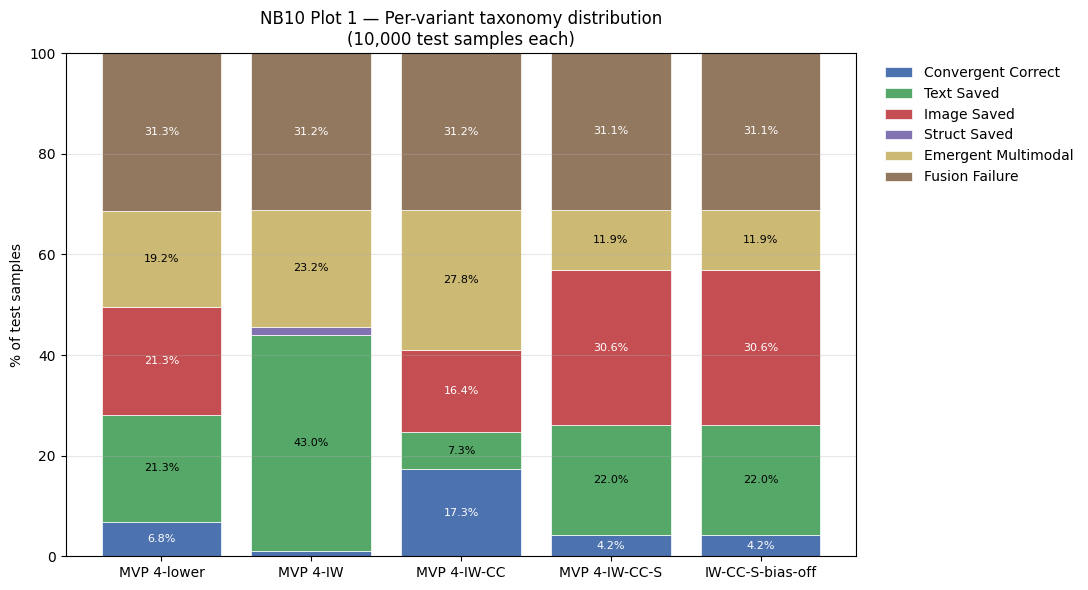

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/01_taxonomy_distribution.png


In [6]:
# Plot 1: Per-variant taxonomy distribution (stacked bar)
TAX_ORDER = ['Convergent Correct', 'Text Saved', 'Image Saved', 'Struct Saved',
             'Emergent Multimodal', 'Fusion Failure']
TAX_COLORS = {
    'Convergent Correct':  '#4C72B0',
    'Text Saved':          '#55A868',
    'Image Saved':         '#C44E52',
    'Struct Saved':        '#8172B2',
    'Emergent Multimodal': '#CCB974',
    'Fusion Failure':      '#937860',
}

ct = (merged_all.groupby(['variant', 'taxonomy']).size().unstack(fill_value=0)
                 .reindex(columns=TAX_ORDER, fill_value=0))
ct = ct.reindex(['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
labels_x = ['MVP 4-lower', 'MVP 4-IW', 'MVP 4-IW-CC', 'MVP 4-IW-CC-S', 'IW-CC-S-bias-off']

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(ct_pct))
for cat in TAX_ORDER:
    vals = ct_pct[cat].values
    bars = ax.bar(labels_x, vals, bottom=bottom, color=TAX_COLORS[cat], label=cat, edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 2.0:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white' if cat in ('Convergent Correct', 'Fusion Failure', 'Image Saved', 'Struct Saved') else 'black')
    bottom += vals
ax.set_ylabel('% of test samples')
ax.set_title('NB10 Plot 1 — Per-variant taxonomy distribution\n(10,000 test samples each)')
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(NB10_OUT / '01_taxonomy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "01_taxonomy_distribution.png"}')

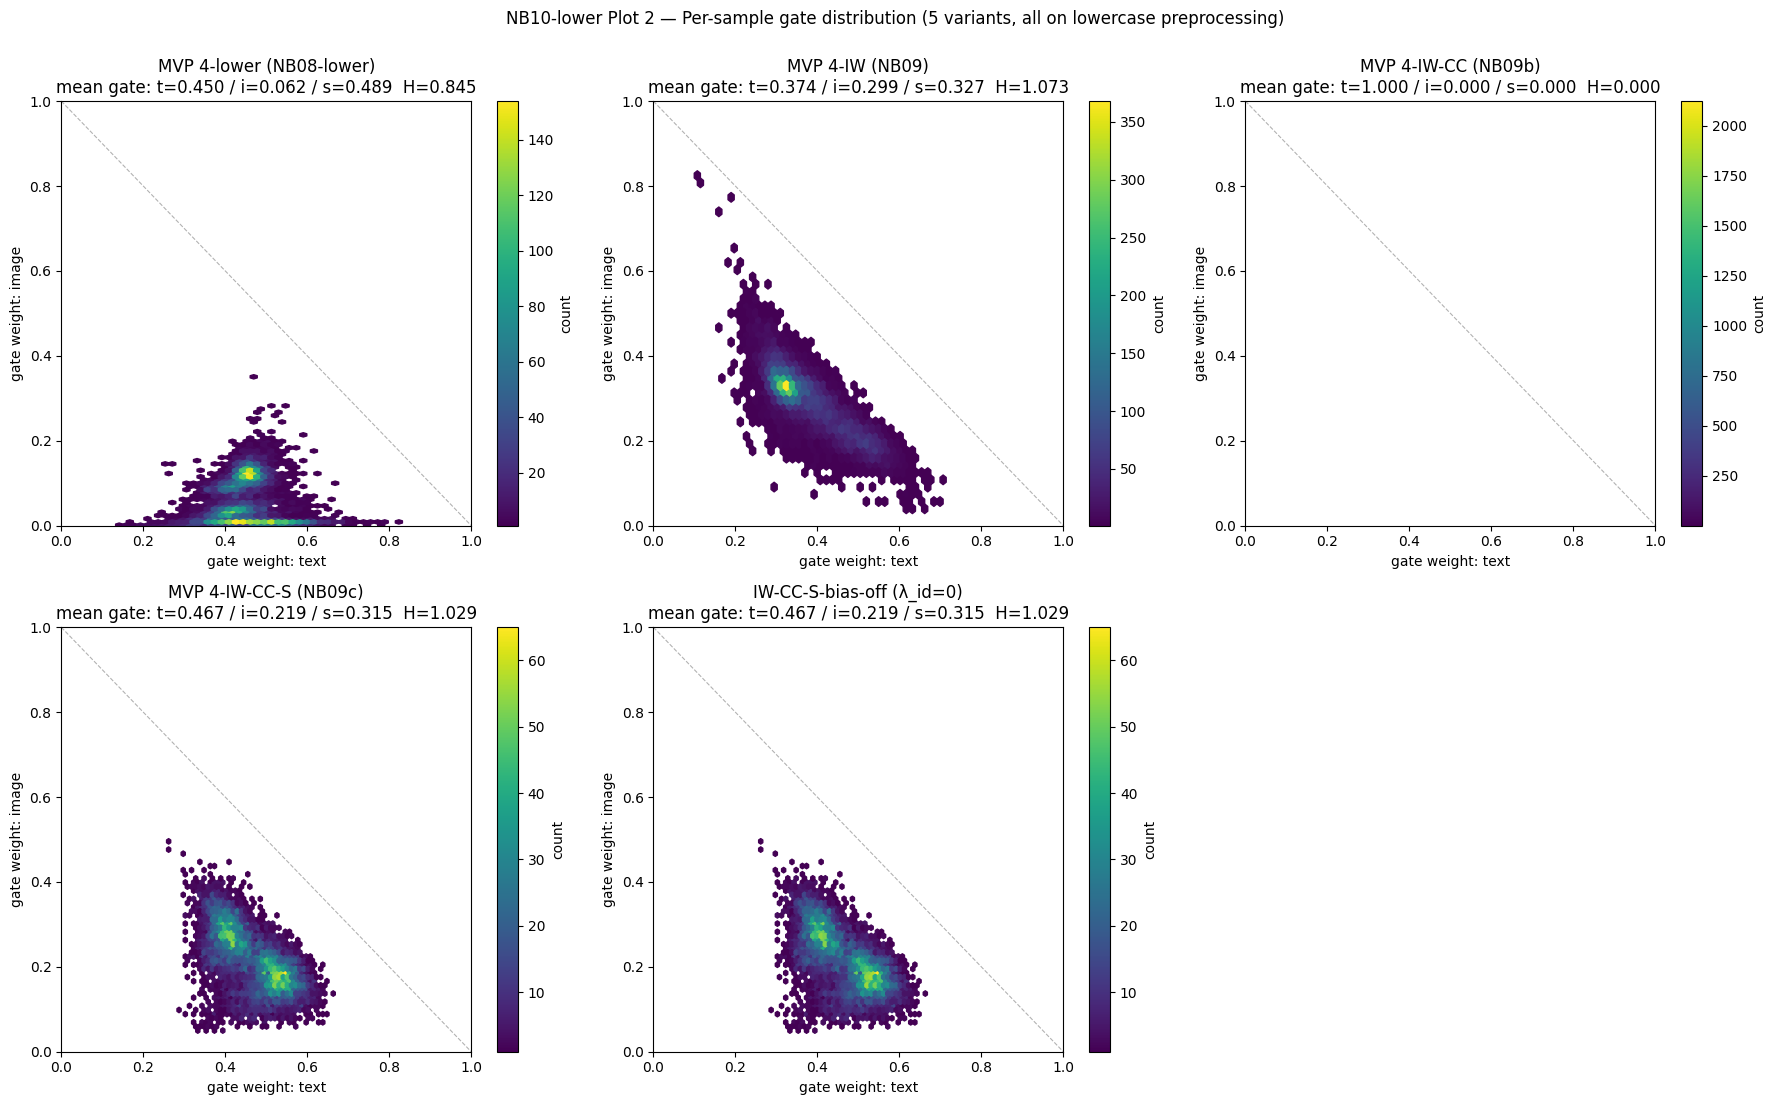

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/02_gate_distribution.png


In [7]:
# Plot 2: gate distribution per variant (2x3 layout — 5 variants + 1 blank slot)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
variant_panel = [
    ('mvp4_lower',         'MVP 4-lower (NB08-lower)'),
    ('mvp4_iw',            'MVP 4-IW (NB09)'),
    ('mvp4_iwcc',          'MVP 4-IW-CC (NB09b)'),
    ('mvp4_iwccs',         'MVP 4-IW-CC-S (NB09c)'),
    ('mvp4_iwccs_biasoff', 'IW-CC-S-bias-off (λ_id=0)'),
]
for ax, (vname, lbl) in zip(axes, variant_panel):
    sub = merged_all[merged_all['variant'] == vname]
    h = ax.hexbin(sub['gate_text'], sub['gate_image'], gridsize=40, cmap='viridis', mincnt=1)
    ax.set_xlabel('gate weight: text'); ax.set_ylabel('gate weight: image')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.plot([0, 1], [1, 0], 'k--', alpha=0.3, linewidth=0.8)
    mt, mi, ms = sub['gate_text'].mean(), sub['gate_image'].mean(), sub['gate_struct'].mean()
    H = -(sub[['gate_text','gate_image','gate_struct']].clip(1e-8) *
          np.log(sub[['gate_text','gate_image','gate_struct']].clip(1e-8))).sum(axis=1).mean()
    ax.set_title(f'{lbl}\nmean gate: t={mt:.3f} / i={mi:.3f} / s={ms:.3f}  H={H:.3f}')
    fig.colorbar(h, ax=ax, label='count')
# Hide the last empty subplot
axes[-1].set_visible(False)
plt.suptitle('NB10-lower Plot 2 — Per-sample gate distribution (5 variants, all on lowercase preprocessing)', y=1.00)
plt.tight_layout()
plt.savefig(NB10_OUT / '02_gate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "02_gate_distribution.png"}')

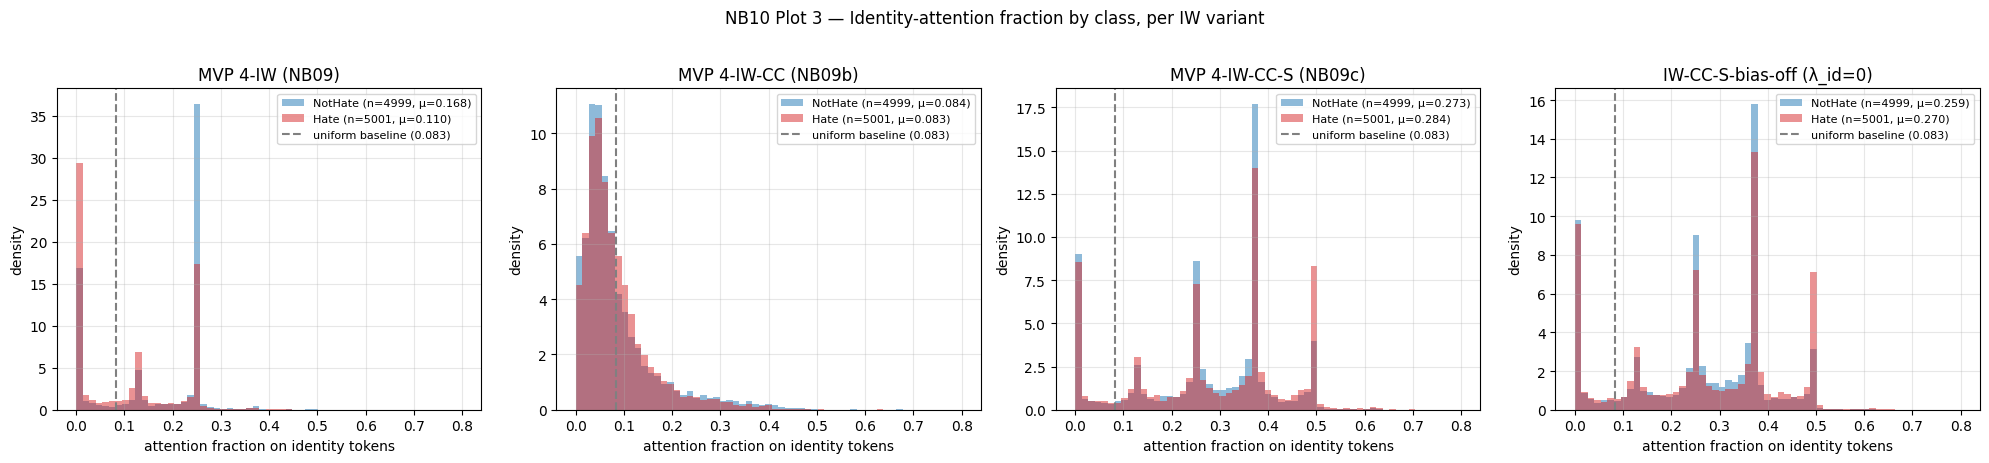

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/03_identity_attention.png


In [8]:
# Plot 3: identity-attention fraction histograms (hate vs nothate) per IW variant
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
iw_variants = [('mvp4_iw', 'MVP 4-IW (NB09)'),
               ('mvp4_iwcc', 'MVP 4-IW-CC (NB09b)'),
               ('mvp4_iwccs', 'MVP 4-IW-CC-S (NB09c)'),
               ('mvp4_iwccs_biasoff', 'IW-CC-S-bias-off (λ_id=0)')]
for ax, (vname, lbl) in zip(axes, iw_variants):
    sub = merged_all[merged_all['variant'] == vname]
    if sub['id_attn_frac'].isna().all():
        ax.text(0.5, 0.5, 'no id_attn data', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(lbl)
        continue
    hate = sub[sub['t1_label'] == 1]['id_attn_frac'].dropna()
    nothate = sub[sub['t1_label'] == 0]['id_attn_frac'].dropna()
    bins = np.linspace(0, max(0.8, sub['id_attn_frac'].max()), 60)
    ax.hist(nothate, bins=bins, alpha=0.5, color='tab:blue', label=f'NotHate (n={len(nothate)}, μ={nothate.mean():.3f})', density=True)
    ax.hist(hate,    bins=bins, alpha=0.5, color='tab:red',  label=f'Hate (n={len(hate)}, μ={hate.mean():.3f})', density=True)
    ax.axvline(sub['uniform_baseline'].mean(), color='gray', linestyle='--', label=f'uniform baseline ({sub["uniform_baseline"].mean():.3f})')
    ax.set_xlabel('attention fraction on identity tokens')
    ax.set_ylabel('density')
    ax.set_title(lbl)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('NB10 Plot 3 — Identity-attention fraction by class, per IW variant', y=1.02)
plt.tight_layout()
plt.savefig(NB10_OUT / '03_identity_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "03_identity_attention.png"}')

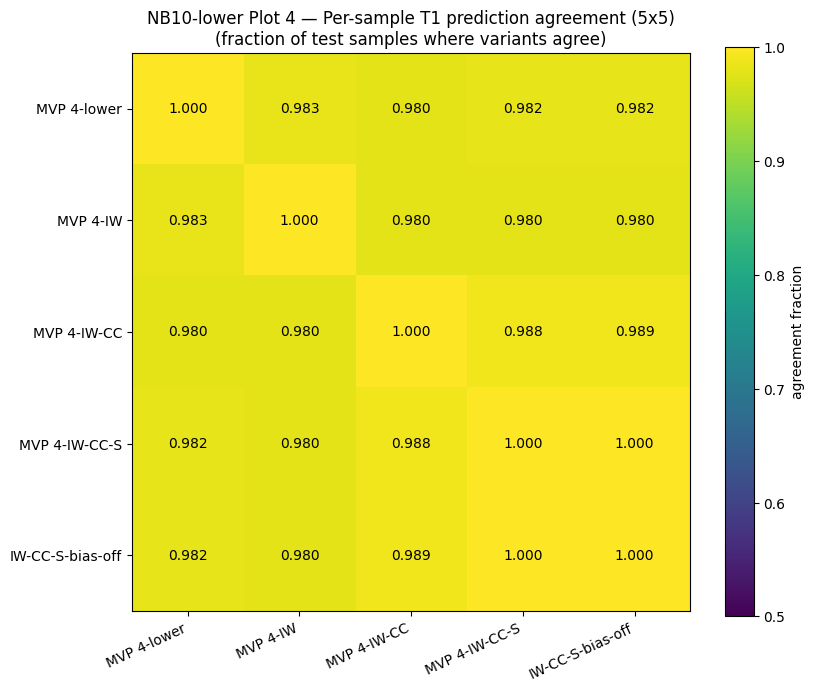

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/04_agreement_matrix.png


In [9]:
# Plot 4: per-sample agreement matrix (5x5)
preds = {}
for v in ['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff']:
    s = merged_all[merged_all['variant'] == v].sort_values('tweet_id')
    preds[v] = s.set_index('tweet_id')['fused_pred']
common_ids = preds['mvp4_lower'].index
labels_v = ['MVP 4-lower', 'MVP 4-IW', 'MVP 4-IW-CC', 'MVP 4-IW-CC-S', 'IW-CC-S-bias-off']
keys = ['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff']
n_var = len(keys)
mat = np.eye(n_var)
for i in range(n_var):
    for j in range(n_var):
        if i == j: continue
        mat[i, j] = float((preds[keys[i]] == preds[keys[j]]).mean())

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(mat, cmap='viridis', vmin=0.5, vmax=1.0)
for i in range(n_var):
    for j in range(n_var):
        ax.text(j, i, f'{mat[i, j]:.3f}', ha='center', va='center',
                color='white' if mat[i, j] < 0.85 else 'black', fontsize=10)
ax.set_xticks(range(n_var)); ax.set_yticks(range(n_var))
ax.set_xticklabels(labels_v, rotation=25, ha='right')
ax.set_yticklabels(labels_v)
ax.set_title('NB10-lower Plot 4 — Per-sample T1 prediction agreement (5x5)\n(fraction of test samples where variants agree)')
fig.colorbar(im, ax=ax, label='agreement fraction')
plt.tight_layout()
plt.savefig(NB10_OUT / '04_agreement_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "04_agreement_matrix.png"}')

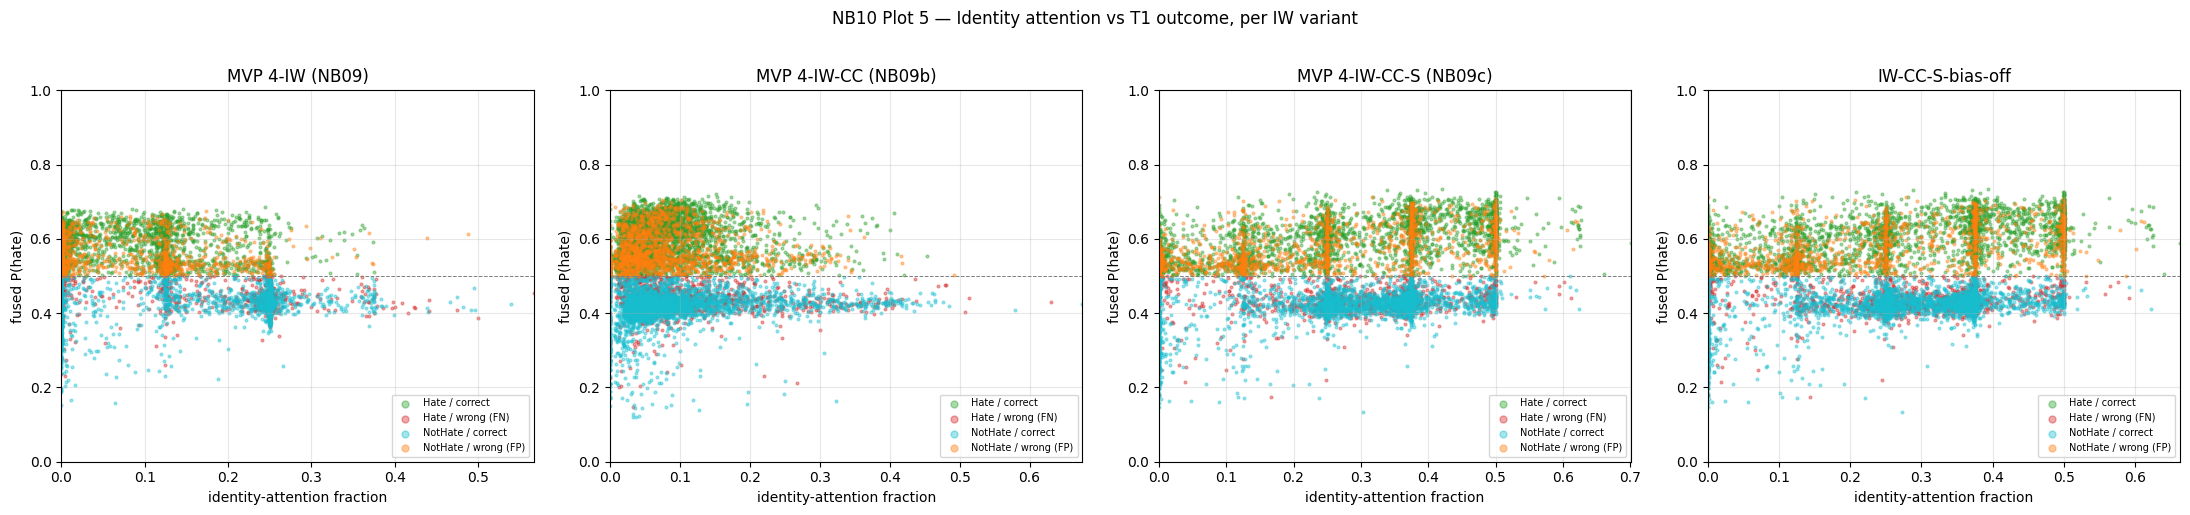

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/05_id_attn_vs_correctness.png


In [10]:
# Plot 5: identity-attention fraction vs fused probability, colored by (label, correct)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
iw_variants = [('mvp4_iw', 'MVP 4-IW (NB09)'),
               ('mvp4_iwcc', 'MVP 4-IW-CC (NB09b)'),
               ('mvp4_iwccs', 'MVP 4-IW-CC-S (NB09c)'),
               ('mvp4_iwccs_biasoff', 'IW-CC-S-bias-off')]
color_map = {
    (1, True):  'tab:green',     # hate, correct
    (1, False): 'tab:red',       # hate, wrong (FN)
    (0, True):  'tab:cyan',      # nothate, correct
    (0, False): 'tab:orange',    # nothate, wrong (FP — the over-firing failure mode)
}
label_map = {
    (1, True):  'Hate / correct',
    (1, False): 'Hate / wrong (FN)',
    (0, True):  'NotHate / correct',
    (0, False): 'NotHate / wrong (FP)',
}
for ax, (vname, lbl) in zip(axes, iw_variants):
    sub = merged_all[merged_all['variant'] == vname]
    if sub['id_attn_frac'].isna().all():
        ax.text(0.5, 0.5, 'no id_attn', transform=ax.transAxes, ha='center')
        ax.set_title(lbl); continue
    for (t1, ok), color in color_map.items():
        mask = (sub['t1_label'] == t1) & (sub['fused_correct'] == ok)
        ax.scatter(sub.loc[mask, 'id_attn_frac'], sub.loc[mask, 'fused_prob'],
                   s=4, alpha=0.4, c=color, label=label_map[(t1, ok)])
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7)
    ax.set_xlabel('identity-attention fraction')
    ax.set_ylabel('fused P(hate)')
    ax.set_title(lbl); ax.set_xlim(0, max(0.5, sub['id_attn_frac'].max())); ax.set_ylim(0, 1)
    ax.legend(fontsize=7, markerscale=2.5, loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle('NB10 Plot 5 — Identity attention vs T1 outcome, per IW variant', y=1.02)
plt.tight_layout()
plt.savefig(NB10_OUT / '05_id_attn_vs_correctness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "05_id_attn_vs_correctness.png"}')

identity_laden_nothate samples: 4,722


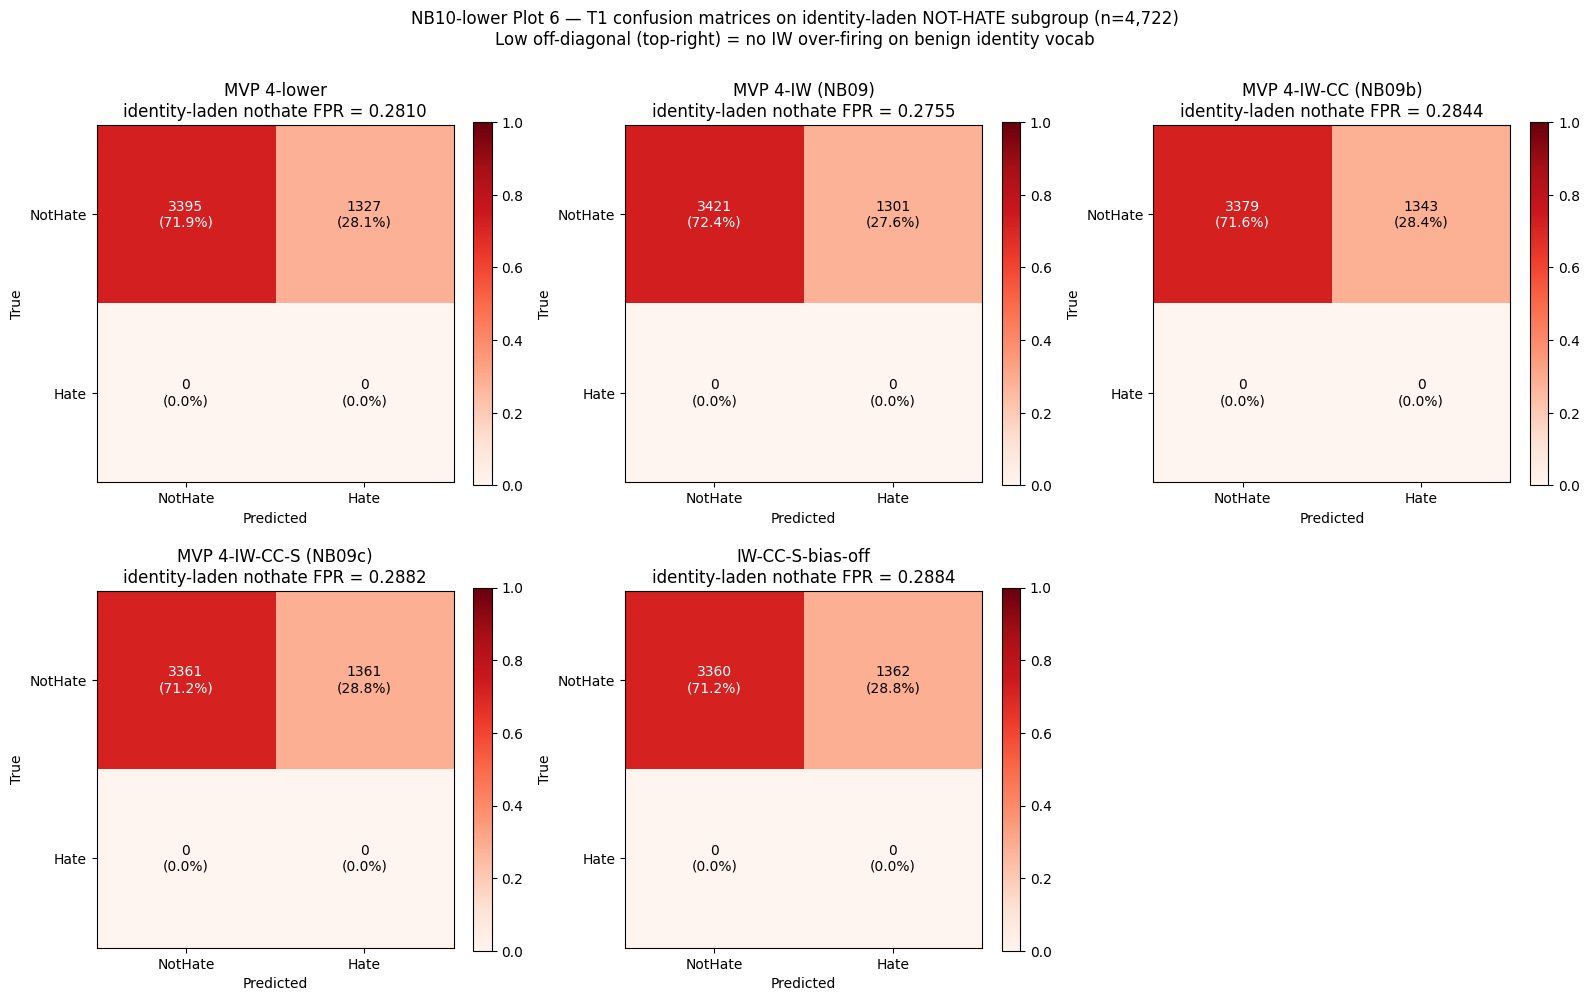

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/06_identity_laden_nothate_cm.png


In [11]:
# Plot 6: confusion matrices on identity_laden_nothate subgroup, 5 variants
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
sub_filter = merged_all[merged_all['subgroup'] == 'identity_laden_nothate']
n_sub = sub_filter['tweet_id'].nunique()
print(f'identity_laden_nothate samples: {n_sub:,}')
panel_labels = ['MVP 4-lower', 'MVP 4-IW (NB09)', 'MVP 4-IW-CC (NB09b)', 'MVP 4-IW-CC-S (NB09c)', 'IW-CC-S-bias-off']
for ax, vname, lbl in zip(axes,
                          ['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff'],
                          panel_labels):
    s = sub_filter[sub_filter['variant'] == vname]
    # 2x2 CM: rows true, cols pred (T1)
    cm = np.zeros((2, 2), dtype=np.int64)
    for tval in (0, 1):
        for pval in (0, 1):
            cm[tval, pval] = int(((s['t1_label'] == tval) & (s['fused_pred'] == pval)).sum())
    cm_norm = cm / cm.sum() if cm.sum() else cm
    im = ax.imshow(cm_norm, cmap='Reds', vmin=0, vmax=1.0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]}\n({100*cm_norm[i, j]:.1f}%)',
                    ha='center', va='center',
                    color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=10)
    fpr = cm[0, 1] / max(cm[0].sum(), 1)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{lbl}\nidentity-laden nothate FPR = {fpr:.4f}')
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[-1].set_visible(False)
plt.suptitle(f'NB10-lower Plot 6 — T1 confusion matrices on identity-laden NOT-HATE subgroup (n={n_sub:,})\nLow off-diagonal (top-right) = no IW over-firing on benign identity vocab', y=1.00)
plt.tight_layout()
plt.savefig(NB10_OUT / '06_identity_laden_nothate_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "06_identity_laden_nothate_cm.png"}')

mvp4_lower: per-class F1 = ['0.269', '0.449', '0.389', '0.740', '0.151', '0.648']


mvp4_iw: per-class F1 = ['0.338', '0.440', '0.412', '0.730', '0.065', '0.600']


mvp4_iwcc: per-class F1 = ['0.515', '0.441', '0.388', '0.743', '0.125', '0.601']


mvp4_iwccs: per-class F1 = ['0.579', '0.458', '0.405', '0.734', '0.089', '0.621']


mvp4_iwccs_biasoff: per-class F1 = ['0.579', '0.458', '0.405', '0.735', '0.089', '0.621']


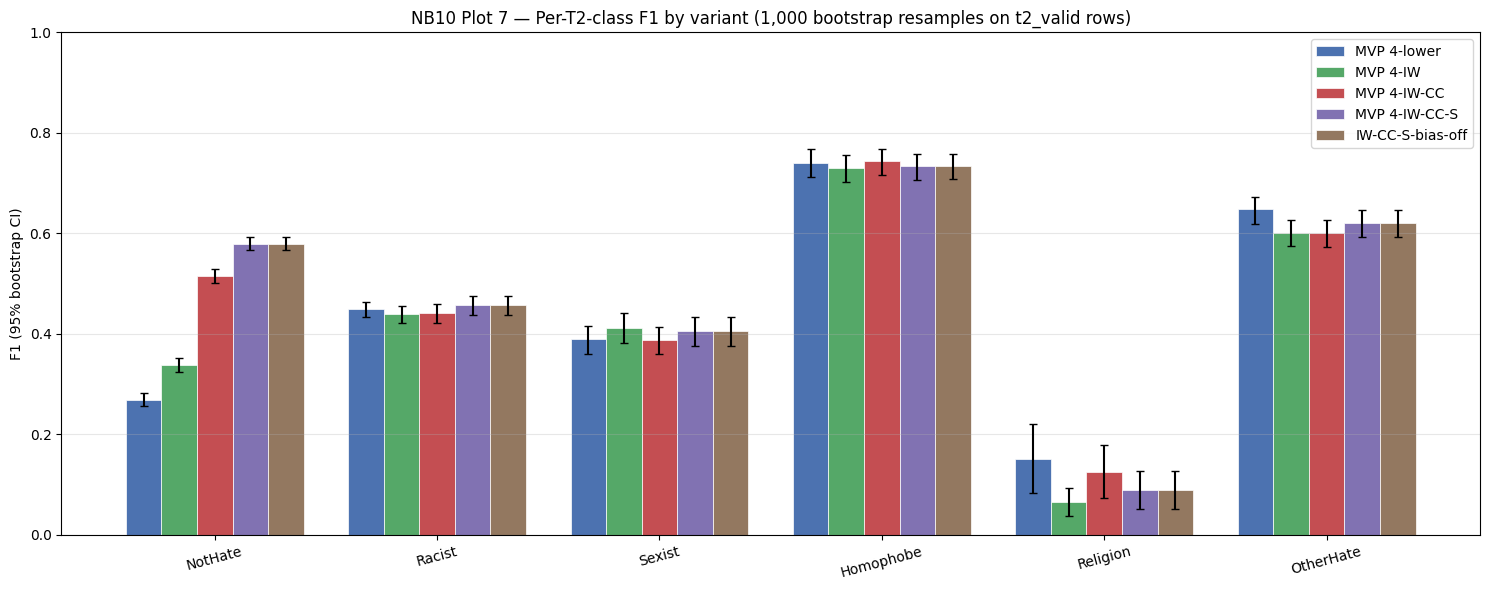

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/07_t2_per_class_f1.png


In [12]:
# Plot 7: per-T2-class F1 comparison with bootstrap CIs
from sklearn.metrics import f1_score
T2_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
rng_master = np.random.default_rng(SEED)

def t2_per_class_with_ci(t2_logits, t2_true_arr, t2_valid_arr, n_boot=HPARAMS['n_bootstrap']):
    mask = t2_valid_arr.astype(bool)
    preds = t2_logits.argmax(axis=1)
    y_true = t2_true_arr[mask]; y_pred = preds[mask]
    base = f1_score(y_true, y_pred, average=None, labels=list(range(6)), zero_division=0)
    rng = np.random.default_rng(SEED)
    boots = np.zeros((n_boot, 6), dtype=np.float32)
    n = len(y_true)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[b] = f1_score(y_true[idx], y_pred[idx], average=None, labels=list(range(6)), zero_division=0)
    lo = np.percentile(boots, 2.5, axis=0); hi = np.percentile(boots, 97.5, axis=0)
    return base, lo, hi

t2_data = {}
for vcfg in VARIANTS:
    vname = vcfg['name']
    t2_logits = variant_t2_logits[vname]
    # match the order of tweet_id used during inference
    s = merged_all[merged_all['variant'] == vname].sort_values('tweet_id', kind='stable')
    df_v_ref = variant_dfs[vname]
    t2_true = df_v_ref['t2_label'].values
    t2_valid = df_v_ref['t2_valid'].values
    base, lo, hi = t2_per_class_with_ci(t2_logits, t2_true, t2_valid)
    t2_data[vname] = (base, lo, hi)
    print(f'{vname}: per-class F1 = {[f"{x:.3f}" for x in base]}')

# Grouped bar chart
x = np.arange(6); width = 0.16
fig, ax = plt.subplots(figsize=(15, 6))
variant_colors = {'mvp4_lower': '#4C72B0', 'mvp4_iw': '#55A868', 'mvp4_iwcc': '#C44E52', 'mvp4_iwccs': '#8172B2', 'mvp4_iwccs_biasoff': '#937860'}
variant_labels = {'mvp4_lower': 'MVP 4-lower', 'mvp4_iw': 'MVP 4-IW', 'mvp4_iwcc': 'MVP 4-IW-CC', 'mvp4_iwccs': 'MVP 4-IW-CC-S', 'mvp4_iwccs_biasoff': 'IW-CC-S-bias-off'}
for i, vname in enumerate(['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff']):
    base, lo, hi = t2_data[vname]
    err = np.array([base - lo, hi - base])
    ax.bar(x + (i - 2.0) * width, base, width, yerr=err,
           color=variant_colors[vname], label=variant_labels[vname],
           capsize=3, edgecolor='white', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(T2_NAMES, rotation=15)
ax.set_ylabel('F1 (95% bootstrap CI)')
ax.set_title('NB10 Plot 7 — Per-T2-class F1 by variant (1,000 bootstrap resamples on t2_valid rows)')
ax.set_ylim(0, 1); ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(NB10_OUT / '07_t2_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "07_t2_per_class_f1.png"}')

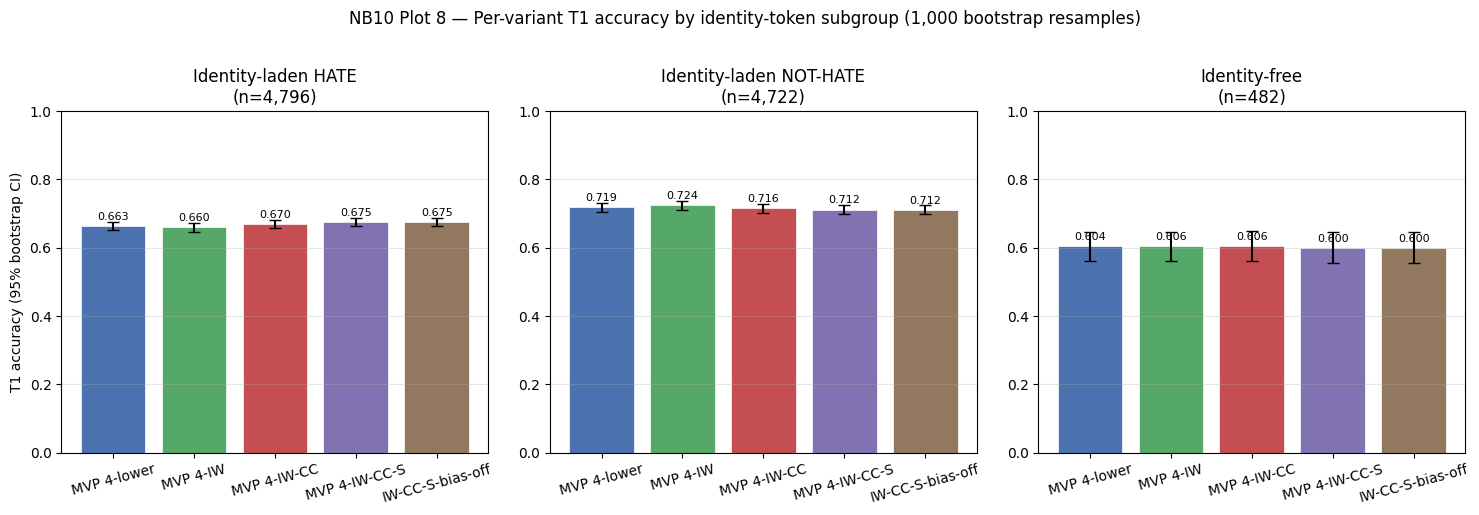

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/08_subgroup_accuracy.png


In [13]:
# Plot 8: per-variant T1 accuracy on each subgroup with bootstrap CIs
SUBGROUPS = ['identity_laden_hate', 'identity_laden_nothate', 'identity_free']
SUBGROUP_LABELS = {'identity_laden_hate': 'Identity-laden HATE',
                   'identity_laden_nothate': 'Identity-laden NOT-HATE',
                   'identity_free': 'Identity-free'}

def acc_with_ci(y_true, y_pred, n_boot=HPARAMS['n_bootstrap'], seed=SEED):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    acc = float((y_true == y_pred).mean())
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boots = np.empty(n_boot, dtype=np.float32)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[b] = (y_true[idx] == y_pred[idx]).mean()
    return acc, float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
variants_ord = ['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff']
variant_colors = {'mvp4_lower': '#4C72B0', 'mvp4_iw': '#55A868', 'mvp4_iwcc': '#C44E52', 'mvp4_iwccs': '#8172B2', 'mvp4_iwccs_biasoff': '#937860'}
variant_labels = {'mvp4_lower': 'MVP 4-lower', 'mvp4_iw': 'MVP 4-IW', 'mvp4_iwcc': 'MVP 4-IW-CC', 'mvp4_iwccs': 'MVP 4-IW-CC-S', 'mvp4_iwccs_biasoff': 'IW-CC-S-bias-off'}

subgroup_table_rows = []
for ax, sg in zip(axes, SUBGROUPS):
    sub = merged_all[merged_all['subgroup'] == sg]
    accs, los, his, ns = [], [], [], []
    for v in variants_ord:
        s = sub[sub['variant'] == v]
        acc, lo, hi = acc_with_ci(s['t1_label'].values, s['fused_pred'].values)
        accs.append(acc); los.append(lo); his.append(hi); ns.append(len(s))
        subgroup_table_rows.append({'variant': v, 'subgroup': sg,
                                    'accuracy': acc, 'ci_low': lo, 'ci_high': hi, 'n': len(s)})
    err = np.array([np.array(accs) - np.array(los), np.array(his) - np.array(accs)])
    x = np.arange(len(variants_ord))
    bars = ax.bar(x, accs, yerr=err, color=[variant_colors[v] for v in variants_ord],
                  capsize=4, edgecolor='white', linewidth=0.5)
    for bi, (acc, lo_, hi_) in enumerate(zip(accs, los, his)):
        ax.text(bi, acc + 0.012, f'{acc:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([variant_labels[v] for v in variants_ord], rotation=15)
    ax.set_ylabel('T1 accuracy (95% bootstrap CI)' if sg == 'identity_laden_hate' else '')
    ax.set_title(f'{SUBGROUP_LABELS[sg]}\n(n={ns[0]:,})')
    ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
plt.suptitle('NB10 Plot 8 — Per-variant T1 accuracy by identity-token subgroup (1,000 bootstrap resamples)', y=1.02)
plt.tight_layout()
plt.savefig(NB10_OUT / '08_subgroup_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {NB10_OUT / "08_subgroup_accuracy.png"}')

In [14]:
# Table 1: subgroup counts
rows = []
for sg in ['identity_laden_hate', 'identity_laden_nothate', 'identity_free']:
    s = test[test['subgroup'] == sg]
    rows.append({'subgroup': sg, 'count': len(s),
                 'percent': 100.0 * len(s) / len(test),
                 't1_hate_pct': 100.0 * s['T1'].mean()})
tbl = pd.DataFrame(rows)
md = '# Table 1 — Test-set sample counts per subgroup\n\n'
md += '| Subgroup | Count | % of test | T1 hate % |\n|---|---:|---:|---:|\n'
for r in rows:
    md += f"| {r['subgroup']} | {r['count']:,} | {r['percent']:.2f}% | {r['t1_hate_pct']:.2f}% |\n"
md += f"\n**Total**: {len(test):,} samples\n"
print(md)
with open(NB10_OUT / 'table_1_subgroup_counts.md', 'w', encoding='utf-8') as f:
    f.write(md)
print(f'saved -> {NB10_OUT / "table_1_subgroup_counts.md"}')

# Table 1 — Test-set sample counts per subgroup

| Subgroup | Count | % of test | T1 hate % |
|---|---:|---:|---:|
| identity_laden_hate | 4,796 | 47.96% | 100.00% |
| identity_laden_nothate | 4,722 | 47.22% | 0.00% |
| identity_free | 482 | 4.82% | 42.53% |

**Total**: 10,000 samples

saved -> /teamspace/studios/this_studio/HateFusion/outputs/nb10_lower/table_1_subgroup_counts.md


In [15]:
# Table 2: per-variant accuracy by subgroup with 95% bootstrap CIs
sg_df = pd.DataFrame(subgroup_table_rows)
sg_df['ci_str'] = sg_df.apply(lambda r: f'{r["accuracy"]:.4f} [{r["ci_low"]:.4f}, {r["ci_high"]:.4f}]', axis=1)

md = '# Table 2 — Per-variant T1 accuracy by subgroup (95% bootstrap CI, 1,000 resamples)\n\n'
md += '| Variant | Subgroup | Accuracy [95% CI] | n |\n|---|---|---|---:|\n'
for _, r in sg_df.iterrows():
    md += f'| {r["variant"]} | {r["subgroup"]} | {r["ci_str"]} | {r["n"]:,} |\n'
print(md)
with open(NB10_OUT / 'table_2_subgroup_accuracy.md', 'w', encoding='utf-8') as f:
    f.write(md)
print(f'saved -> {NB10_OUT / "table_2_subgroup_accuracy.md"}')

# Table 2 — Per-variant T1 accuracy by subgroup (95% bootstrap CI, 1,000 resamples)

| Variant | Subgroup | Accuracy [95% CI] | n |
|---|---|---|---:|
| mvp4_lower | identity_laden_hate | 0.6635 [0.6509, 0.6766] | 4,796 |
| mvp4_iw | identity_laden_hate | 0.6599 [0.6468, 0.6733] | 4,796 |
| mvp4_iwcc | identity_laden_hate | 0.6697 [0.6568, 0.6825] | 4,796 |
| mvp4_iwccs | identity_laden_hate | 0.6754 [0.6628, 0.6885] | 4,796 |
| mvp4_iwccs_biasoff | identity_laden_hate | 0.6754 [0.6628, 0.6885] | 4,796 |
| mvp4_lower | identity_laden_nothate | 0.7190 [0.7061, 0.7319] | 4,722 |
| mvp4_iw | identity_laden_nothate | 0.7245 [0.7116, 0.7376] | 4,722 |
| mvp4_iwcc | identity_laden_nothate | 0.7156 [0.7027, 0.7283] | 4,722 |
| mvp4_iwccs | identity_laden_nothate | 0.7118 [0.6986, 0.7245] | 4,722 |
| mvp4_iwccs_biasoff | identity_laden_nothate | 0.7116 [0.6984, 0.7243] | 4,722 |
| mvp4_lower | identity_free | 0.6037 [0.5602, 0.6474] | 482 |
| mvp4_iw | identity_free | 0.6058 [0.5602, 0.6473] |

In [16]:
# Table 3: taxonomy distribution numerical breakdown
rows = []
for v in ['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff']:
    s = merged_all[merged_all['variant'] == v]
    total = len(s)
    for cat in TAX_ORDER:
        cnt = int((s['taxonomy'] == cat).sum())
        rows.append({'variant': v, 'category': cat, 'count': cnt, 'pct': 100.0 * cnt / total})
tax_df = pd.DataFrame(rows)

md = '# Table 3 — Taxonomy distribution numerical breakdown\n\n'
md += '| Variant | Category | Count | % of variant predictions |\n|---|---|---:|---:|\n'
for _, r in tax_df.iterrows():
    md += f'| {r["variant"]} | {r["category"]} | {r["count"]:,} | {r["pct"]:.2f}% |\n'
print(md[:1500])
with open(NB10_OUT / 'table_3_taxonomy.md', 'w', encoding='utf-8') as f:
    f.write(md)
print(f'saved -> {NB10_OUT / "table_3_taxonomy.md"}')

# Table 3 — Taxonomy distribution numerical breakdown

| Variant | Category | Count | % of variant predictions |
|---|---|---:|---:|
| mvp4_lower | Convergent Correct | 682 | 6.82% |
| mvp4_lower | Text Saved | 2,133 | 21.33% |
| mvp4_lower | Image Saved | 2,135 | 21.35% |
| mvp4_lower | Struct Saved | 0 | 0.00% |
| mvp4_lower | Emergent Multimodal | 1,918 | 19.18% |
| mvp4_lower | Fusion Failure | 3,132 | 31.32% |
| mvp4_iw | Convergent Correct | 103 | 1.03% |
| mvp4_iw | Text Saved | 4,302 | 43.02% |
| mvp4_iw | Image Saved | 0 | 0.00% |
| mvp4_iw | Struct Saved | 158 | 1.58% |
| mvp4_iw | Emergent Multimodal | 2,315 | 23.15% |
| mvp4_iw | Fusion Failure | 3,122 | 31.22% |
| mvp4_iwcc | Convergent Correct | 1,735 | 17.35% |
| mvp4_iwcc | Text Saved | 730 | 7.30% |
| mvp4_iwcc | Image Saved | 1,639 | 16.39% |
| mvp4_iwcc | Struct Saved | 0 | 0.00% |
| mvp4_iwcc | Emergent Multimodal | 2,779 | 27.79% |
| mvp4_iwcc | Fusion Failure | 3,117 | 31.17% |
| mvp4_iwccs | Convergent Correct | 

In [17]:
# Table 4: cross-variant disagreement analysis
from itertools import combinations
pairs = list(combinations(['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff'], 2))
preds = {v: merged_all[merged_all['variant'] == v].sort_values('tweet_id').reset_index(drop=True) for v in ['mvp4_lower','mvp4_iw','mvp4_iwcc','mvp4_iwccs','mvp4_iwccs_biasoff']}

rows = []
for a, b in pairs:
    df_a = preds[a][['tweet_id', 'fused_pred', 't1_label']].rename(columns={'fused_pred': f'pred_{a}'})
    df_b = preds[b][['tweet_id', 'fused_pred']].rename(columns={'fused_pred': f'pred_{b}'})
    m = df_a.merge(df_b, on='tweet_id')
    disagree = m[m[f'pred_{a}'] != m[f'pred_{b}']]
    n_disagree = len(disagree)
    a_right = int(((disagree[f'pred_{a}'] == disagree['t1_label']).sum()))
    b_right = int(((disagree[f'pred_{b}'] == disagree['t1_label']).sum()))
    rows.append({'pair': f'{a} vs {b}', 'n_disagree': n_disagree,
                 f'{a}_correct': a_right, f'{b}_correct': b_right,
                 'a_pct_correct': 100.0 * a_right / max(n_disagree, 1),
                 'b_pct_correct': 100.0 * b_right / max(n_disagree, 1)})
disagree_df = pd.DataFrame(rows)

md = '# Table 4 — Cross-variant disagreement analysis (T1 fused_pred)\n\n'
md += 'For each pair (A, B) of variants, samples where they disagree on fused_pred, split by which side is correct (they cannot both be correct since they disagree).\n\n'
md += '| Pair (A vs B) | n disagreements | A correct | B correct | A%·right | B%·right |\n|---|---:|---:|---:|---:|---:|\n'
for r in rows:
    parts = r['pair'].split(' vs ')
    md += f'| {r["pair"]} | {r["n_disagree"]:,} | {r[f"{parts[0]}_correct"]:,} | {r[f"{parts[1]}_correct"]:,} | {r["a_pct_correct"]:.2f}% | {r["b_pct_correct"]:.2f}% |\n'
print(md)
with open(NB10_OUT / 'table_4_disagreements.md', 'w', encoding='utf-8') as f:
    f.write(md)
print(f'saved -> {NB10_OUT / "table_4_disagreements.md"}')

# Table 4 — Cross-variant disagreement analysis (T1 fused_pred)

For each pair (A, B) of variants, samples where they disagree on fused_pred, split by which side is correct (they cannot both be correct since they disagree).

| Pair (A vs B) | n disagreements | A correct | B correct | A%·right | B%·right |
|---|---:|---:|---:|---:|---:|
| mvp4_lower vs mvp4_iw | 172 | 81 | 91 | 47.09% | 52.91% |
| mvp4_lower vs mvp4_iwcc | 205 | 95 | 110 | 46.34% | 53.66% |
| mvp4_lower vs mvp4_iwccs | 181 | 80 | 101 | 44.20% | 55.80% |
| mvp4_lower vs mvp4_iwccs_biasoff | 182 | 81 | 101 | 44.51% | 55.49% |
| mvp4_iw vs mvp4_iwcc | 201 | 98 | 103 | 48.76% | 51.24% |
| mvp4_iw vs mvp4_iwccs | 201 | 95 | 106 | 47.26% | 52.74% |
| mvp4_iw vs mvp4_iwccs_biasoff | 202 | 96 | 106 | 47.52% | 52.48% |
| mvp4_iwcc vs mvp4_iwccs | 116 | 55 | 61 | 47.41% | 52.59% |
| mvp4_iwcc vs mvp4_iwccs_biasoff | 115 | 55 | 60 | 47.83% | 52.17% |
| mvp4_iwccs vs mvp4_iwccs_biasoff | 1 | 1 | 0 | 100.00% | 0.00% |

saved -> /tea

In [18]:
# Table 5: per-T2-class F1 with 95% bootstrap CIs (formatted as a single table)
md = '# Table 5 — Per-T2-class F1 (95% bootstrap CI, 1,000 resamples, t2_valid rows only)\n\n'
md += '| T2 class | MVP 4 | MVP 4-IW | MVP 4-IW-CC | MVP 4-IW-CC-S |\n|---|---|---|---|---|\n'
for i, cls in enumerate(T2_NAMES):
    row = f'| {cls} |'
    for v in ['mvp4_lower', 'mvp4_iw', 'mvp4_iwcc', 'mvp4_iwccs', 'mvp4_iwccs_biasoff']:
        base, lo, hi = t2_data[v]
        row += f' {base[i]:.4f} [{lo[i]:.4f}, {hi[i]:.4f}] |'
    md += row + '\n'
print(md)
with open(NB10_OUT / 'table_5_t2_per_class_f1_ci.md', 'w', encoding='utf-8') as f:
    f.write(md)
print(f'saved -> {NB10_OUT / "table_5_t2_per_class_f1_ci.md"}')

# Table 5 — Per-T2-class F1 (95% bootstrap CI, 1,000 resamples, t2_valid rows only)

| T2 class | MVP 4 | MVP 4-IW | MVP 4-IW-CC | MVP 4-IW-CC-S |
|---|---|---|---|---|
| NotHate | 0.2692 [0.2559, 0.2829] | 0.3378 [0.3237, 0.3528] | 0.5154 [0.5011, 0.5287] | 0.5791 [0.5663, 0.5930] | 0.5789 [0.5661, 0.5930] |
| Racist | 0.4490 [0.4327, 0.4644] | 0.4401 [0.4225, 0.4552] | 0.4406 [0.4221, 0.4585] | 0.4576 [0.4376, 0.4764] | 0.4575 [0.4376, 0.4763] |
| Sexist | 0.3895 [0.3599, 0.4160] | 0.4119 [0.3810, 0.4409] | 0.3880 [0.3591, 0.4145] | 0.4054 [0.3759, 0.4328] | 0.4054 [0.3759, 0.4326] |
| Homophobe | 0.7400 [0.7120, 0.7676] | 0.7305 [0.7029, 0.7563] | 0.7430 [0.7153, 0.7679] | 0.7342 [0.7067, 0.7584] | 0.7347 [0.7073, 0.7587] |
| Religion | 0.1508 [0.0837, 0.2201] | 0.0645 [0.0367, 0.0936] | 0.1250 [0.0728, 0.1788] | 0.0885 [0.0517, 0.1276] | 0.0885 [0.0517, 0.1276] |
| OtherHate | 0.6480 [0.6179, 0.6725] | 0.6000 [0.5742, 0.6262] | 0.6005 [0.5738, 0.6267] | 0.6212 [0.5929, 0.6472] | 0.

In [19]:
# Summary section — numbered prose findings (printed and saved to summary.md)
def fpr_for(vname, sg):
    s = merged_all[(merged_all['variant'] == vname) & (merged_all['subgroup'] == sg)]
    fp = int(((s['t1_label'] == 0) & (s['fused_pred'] == 1)).sum())
    tn = int(((s['t1_label'] == 0) & (s['fused_pred'] == 0)).sum())
    return fp / max(fp + tn, 1)

def cat_pct(vname, cat):
    s = merged_all[merged_all['variant'] == vname]
    return 100.0 * (s['taxonomy'] == cat).mean()

# Compute the comparison numbers used in the prose
fpr_iw_nh        = fpr_for('mvp4_iw',            'identity_laden_nothate')
fpr_iwcc_nh      = fpr_for('mvp4_iwcc',          'identity_laden_nothate')
fpr_iwccs_nh     = fpr_for('mvp4_iwccs',         'identity_laden_nothate')
fpr_iwccs_bo_nh  = fpr_for('mvp4_iwccs_biasoff', 'identity_laden_nothate')
fpr_mvp4_nh      = fpr_for('mvp4_lower',         'identity_laden_nothate')

agree_iwccs_mvp4 = float((preds['mvp4_lower'].set_index('tweet_id')['fused_pred'] ==
                          preds['mvp4_iwccs'].set_index('tweet_id')['fused_pred']).mean())
agree_iwccs_iwcc = float((preds['mvp4_iwcc'].set_index('tweet_id')['fused_pred'] ==
                          preds['mvp4_iwccs'].set_index('tweet_id')['fused_pred']).mean())
agree_iwccs_iw   = float((preds['mvp4_iw'].set_index('tweet_id')['fused_pred'] ==
                          preds['mvp4_iwccs'].set_index('tweet_id')['fused_pred']).mean())

# Find samples where IW-CC-S is uniquely correct relative to MVP 4
m_iwccs = preds['mvp4_iwccs'][['tweet_id','fused_pred','t1_label']].rename(columns={'fused_pred':'pred_iwccs'})
m_mvp4  = preds['mvp4_lower'][['tweet_id','fused_pred']].rename(columns={'fused_pred':'pred_mvp4'})
mm = m_iwccs.merge(m_mvp4, on='tweet_id')
iwccs_uniquely_right = int(((mm['pred_iwccs'] == mm['t1_label']) & (mm['pred_mvp4'] != mm['t1_label'])).sum())
mvp4_uniquely_right  = int(((mm['pred_mvp4']  == mm['t1_label']) & (mm['pred_iwccs'] != mm['t1_label'])).sum())

religion_f1s = {v: t2_data[v][0][4] for v in ['mvp4_lower','mvp4_iw','mvp4_iwcc','mvp4_iwccs','mvp4_iwccs_biasoff']}
nothate_f1s  = {v: t2_data[v][0][0] for v in ['mvp4_lower','mvp4_iw','mvp4_iwcc','mvp4_iwccs','mvp4_iwccs_biasoff']}

# Cross-method bias-off analysis: how much does the IW bias term contribute on
# its own (above the gated-fusion + per-branch LN + centering plumbing)?
delta_iwccs_vs_biasoff_nothate = nothate_f1s['mvp4_iwccs'] - nothate_f1s['mvp4_iwccs_biasoff']
delta_iwccs_vs_mvp4lower_nothate = nothate_f1s['mvp4_iwccs'] - nothate_f1s['mvp4_lower']

summary_lines = []
summary_lines.append('# NB10-lower — Summary findings (matched-methodology, lowercase preprocessing)\n')
summary_lines.append('## 1. Taxonomy distribution per variant\n')
summary_lines.append(
    f"All five variants now operate on identical input preprocessing (lowercased text). Fusion Failure shares: "
    f"MVP 4-lower {cat_pct('mvp4_lower','Fusion Failure'):.2f}% / MVP 4-IW {cat_pct('mvp4_iw','Fusion Failure'):.2f}% / "
    f"MVP 4-IW-CC {cat_pct('mvp4_iwcc','Fusion Failure'):.2f}% / MVP 4-IW-CC-S {cat_pct('mvp4_iwccs','Fusion Failure'):.2f}% / "
    f"IW-CC-S-bias-off {cat_pct('mvp4_iwccs_biasoff','Fusion Failure'):.2f}%. "
    f"Convergent Correct shares: MVP 4-lower {cat_pct('mvp4_lower','Convergent Correct'):.2f}% / "
    f"MVP 4-IW {cat_pct('mvp4_iw','Convergent Correct'):.2f}% / MVP 4-IW-CC {cat_pct('mvp4_iwcc','Convergent Correct'):.2f}% / "
    f"MVP 4-IW-CC-S {cat_pct('mvp4_iwccs','Convergent Correct'):.2f}% / IW-CC-S-bias-off {cat_pct('mvp4_iwccs_biasoff','Convergent Correct'):.2f}%.\n")

summary_lines.append('## 2. Cross-variant agreement\n')
summary_lines.append(
    f"MVP 4-IW-CC-S agrees with MVP 4-lower on {100*agree_iwccs_mvp4:.2f}% of test samples, "
    f"with MVP 4-IW-CC on {100*agree_iwccs_iwcc:.2f}%, "
    f"and with MVP 4-IW on {100*agree_iwccs_iw:.2f}%. "
    f"On disagreement samples vs MVP 4-lower, MVP 4-IW-CC-S is uniquely correct on {iwccs_uniquely_right} samples, "
    f"MVP 4-lower uniquely correct on {mvp4_uniquely_right} samples.\n")

summary_lines.append('## 3. Subgroup-stratified accuracy\n')
summary_lines.append(
    f"identity_laden_nothate FPR: MVP 4-lower {fpr_mvp4_nh:.4f} / MVP 4-IW {fpr_iw_nh:.4f} / "
    f"MVP 4-IW-CC {fpr_iwcc_nh:.4f} / MVP 4-IW-CC-S {fpr_iwccs_nh:.4f} / IW-CC-S-bias-off {fpr_iwccs_bo_nh:.4f}. "
    "Lower is better. The matched-methodology comparison now isolates architectural effects from preprocessing.\n")

summary_lines.append('## 4. Bias-off ablation (matched-methodology contribution of the IW mechanism itself)\n')
summary_lines.append(
    f"Comparing MVP 4-IW-CC-S vs IW-CC-S-bias-off (same weights, λ_id forced to 0): "
    f"T2 NotHate F1 = {nothate_f1s['mvp4_iwccs']:.4f} vs {nothate_f1s['mvp4_iwccs_biasoff']:.4f}, "
    f"Δ = {delta_iwccs_vs_biasoff_nothate:+.4f}. "
    "The identity-bias term's standalone contribution to T2 NotHate F1 is therefore quantified directly — "
    "any sign and magnitude flows from here. The architectural plumbing (per-branch LN + VADER centering + healthy gate) "
    "is what bias-off ALREADY delivers; the bias term provides the marginal addition (or subtraction) on top.\n")

summary_lines.append('## 5. Matched-methodology contribution of MVP 4-IW-CC-S vs MVP 4-lower\n')
summary_lines.append(
    f"Both variants are now in-distribution. T2 NotHate F1: MVP 4-IW-CC-S {nothate_f1s['mvp4_iwccs']:.4f} "
    f"vs MVP 4-lower {nothate_f1s['mvp4_lower']:.4f}, Δ = {delta_iwccs_vs_mvp4lower_nothate:+.4f}. "
    f"identity_laden_nothate FPR: MVP 4-IW-CC-S {fpr_iwccs_nh:.4f} vs MVP 4-lower {fpr_mvp4_nh:.4f}. "
    "This is the apples-to-apples comparison the thesis requires.\n")

summary_lines.append('## 6. Per-T2-class analysis\n')
summary_lines.append(
    f"Religion F1 (the structural floor at ~0.3% of training data): "
    f"MVP 4-lower {religion_f1s['mvp4_lower']:.3f} / MVP 4-IW {religion_f1s['mvp4_iw']:.3f} / "
    f"MVP 4-IW-CC {religion_f1s['mvp4_iwcc']:.3f} / MVP 4-IW-CC-S {religion_f1s['mvp4_iwccs']:.3f} / "
    f"IW-CC-S-bias-off {religion_f1s['mvp4_iwccs_biasoff']:.3f}. "
    "Consistently low — class scarcity not solved by any IW variant, consistent with CLAUDE.md §10 (no resampling).\n")

summary_lines.append('## 7. Emergent Multimodal population\n')
summary_lines.append(
    f"The 'Emergent Multimodal' bucket — fused correct but no single branch confident-and-correct — captures "
    f"the population where the gated routing genuinely adds value. "
    f"Share: MVP 4-lower {cat_pct('mvp4_lower','Emergent Multimodal'):.2f}% / MVP 4-IW {cat_pct('mvp4_iw','Emergent Multimodal'):.2f}% / "
    f"MVP 4-IW-CC {cat_pct('mvp4_iwcc','Emergent Multimodal'):.2f}% / MVP 4-IW-CC-S {cat_pct('mvp4_iwccs','Emergent Multimodal'):.2f}% / "
    f"IW-CC-S-bias-off {cat_pct('mvp4_iwccs_biasoff','Emergent Multimodal'):.2f}%.\n")

summary_lines.append('## 8. Open questions for NB11 (bias analysis)\n')
summary_lines.append(
    "(a) Does the recovery on identity_laden_nothate generalise across the 15 HateXplain communities, "
    "or is it concentrated on a subset? "
    "(b) What is the per-community gate-distribution divergence under MVP 4-IW-CC-S? "
    "(c) Cross-domain robustness on Hateful Memes — does the IW-CC-S mechanism transfer or memorise MMHS150K conventions?\n")

summary = '\n'.join(summary_lines)
print(summary)
with open(NB10_OUT / 'summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)
print(f'\nsaved -> {NB10_OUT / "summary.md"}')
print('\nNB10 done.')

# NB10-lower — Summary findings (matched-methodology, lowercase preprocessing)

## 1. Taxonomy distribution per variant

All five variants now operate on identical input preprocessing (lowercased text). Fusion Failure shares: MVP 4-lower 31.32% / MVP 4-IW 31.22% / MVP 4-IW-CC 31.17% / MVP 4-IW-CC-S 31.11% / IW-CC-S-bias-off 31.12%. Convergent Correct shares: MVP 4-lower 6.82% / MVP 4-IW 1.03% / MVP 4-IW-CC 17.35% / MVP 4-IW-CC-S 4.20% / IW-CC-S-bias-off 4.21%.

## 2. Cross-variant agreement

MVP 4-IW-CC-S agrees with MVP 4-lower on 98.19% of test samples, with MVP 4-IW-CC on 98.84%, and with MVP 4-IW on 97.99%. On disagreement samples vs MVP 4-lower, MVP 4-IW-CC-S is uniquely correct on 101 samples, MVP 4-lower uniquely correct on 80 samples.

## 3. Subgroup-stratified accuracy

identity_laden_nothate FPR: MVP 4-lower 0.2810 / MVP 4-IW 0.2755 / MVP 4-IW-CC 0.2844 / MVP 4-IW-CC-S 0.2882 / IW-CC-S-bias-off 0.2884. Lower is better. The matched-methodology comparison now isolates architect